In [1]:
import mdtraj as md
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
    'font.size': 8,            # Default font size
    'axes.labelsize': 9,       # Axis title size
    'axes.titlesize': 9,       
    'xtick.labelsize': 8,      # X tick labels
    'ytick.labelsize': 8,      # Y tick labels
    'legend.fontsize': 8,      # Legend
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans', 'sans-serif'],# Use Arial or Helvetica
    'pdf.fonttype': 42         # Editable text in PDFs
})

In [3]:
csv_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/results/model_comparisons.csv'

In [4]:
result=pd.read_csv(csv_path)

In [5]:
result

,name,name_alt,type_a,type_b,comparison,fname_a,fname_b,rmsd,lddt,saxs_kldiv,...,rg_b,rg_diff,plddt_a,plddt_bins_a,plddt_b,plddt_bins_b,saxs_bins_a,saxs_a,saxs_bins_b,saxs_b
0,1MO8-14_A,1MO7-3_A,out_AF,target,out_AF_vs_target,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,20.020442,0.250553,0.140280,...,1.725501,0.330997,[38.98 41.64 40.08 38.9 41.82 40.62 47.12 42....,[ 1 2 3 4 5 6 7 8 9 10 11 ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[383 384 385 386 387 388 389 390 391 392 393 3...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 0.00000000e+00 2.98513331e-06 ...
1,1MO8-14_A,1MO7-3_A,out_NMR,target,out_NMR_vs_target,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,18.229737,0.210920,0.529228,...,1.725501,0.418606,[29.1 30.46 30.7 31.75 33.08 33.68 33.02 31....,[ 1 2 3 4 5 6 7 8 9 10 11 ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[383 384 385 386 387 388 389 390 391 392 393 3...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 2.77219620e-06 3.49296721e-05 ...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 0.00000000e+00 2.98513331e-06 ...
2,1MO8-14_A,1MO7-3_A,out_NMA,target,out_NMA_vs_target,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,20.796509,0.239703,0.241372,...,1.725501,0.312689,[33.79 29.31 33.56 35.02 34.39 37.44 35.08 39....,[ 1 2 3 4 5 6 7 8 9 10 11 ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[383 384 385 386 387 388 389 390 391 392 393 3...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 6.84895531e-07 1.31108573e-05 ...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 0.00000000e+00 2.98513331e-06 ...
3,1MO8-14_A,1MO7-3_A,out_AF,out_alt_AF,out_AF_vs_out_alt_AF,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,1.784786,0.948959,0.000388,...,2.039674,0.016824,[38.98 41.64 40.08 38.9 41.82 40.62 47.12 42....,[ 1 2 3 4 5 6 7 8 9 10 11 ...,[40.95 43.54 41.39 39.65 42.98 41.53 47.89 45....,[ 1 2 3 4 5 6 7 8 9 10 11 ...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...
4,1MO8-14_A,1MO7-3_A,out_NMR,out_alt_NMR,out_NMR_vs_out_alt_NMR,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,3.615357,0.750860,0.006207,...,2.213060,-0.068953,[29.1 30.46 30.7 31.75 33.08 33.68 33.02 31....,[ 1 2 3 4 5 6 7 8 9 10 11 ...,[29.28 30.06 31.51 32.37 34.01 34.84 33.93 32....,[ 1 2 3 4 5 6 7 8 9 10 11 ...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 2.77219620e-06 3.49296721e-05 ...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 1.85900216e-06 2.58466528e-05 ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,2KID-4_A,1IJA-15_A,out_NMA,out_alt_NMA,out_NMA_vs_out_alt_NMA,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,0.204694,0.999395,0.000057,...,1.528825,-0.002023,[27.13 31.73 47. 57.39 65.36 71.63 77.73 75....,[ 1 2 3 4 5 6 7 8 9 10 11 ...,[26.92 31.28 46.29 56.66 65.17 71.05 77.28 74....,[ 1 2 3 4 5 6 7 8 9 10 11 ...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 0.00000000e+00 9.78568322e-06 ...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 0.00000000e+00 8.38772847e-06 ...
796,2KID-4_A,1IJA-15_A,target,target_alt,target_vs_target_alt,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,/global/cfs/cdirs/m4704/100125_Nature_Com_data...,4.538443,0.730218,0.020793,...,1.488638,0.030582,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[ 59 60 61 62 63 64 65 66 67 68 69 ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[ 1 2 3 4 5 6 7 8 9 10 11 ...,[ 0. 0.5 1. 1.5 2. 2.5 3. 3.5 4. ...,[0.00000000e+00 

In [6]:
pair_csv=pd.read_csv('/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/Table_rmsd_Apo_vs_Holo.csv',sep=';')
pair_dict={}
for index, i in pair_csv.iterrows():
    pair_dict[i['Apo_ID']]=i['Holo_ID']

In [7]:
apo_ids=list(pair_dict.keys())

In [8]:
holo_ids=list(pair_dict.values())

In [9]:
AF_result=result[(result['type_a']=='out_AF')&(result['type_b']=='target')][['name','rmsd','saxs_l1','rg_diff']]
AF_result['rg_diff_A']=AF_result['rg_diff']*10

In [10]:
NMR_result=result[(result['type_a']=='out_NMR')&(result['type_b']=='target')][['name','rmsd','saxs_l1','rg_diff']]
NMR_result['rg_diff_A']=NMR_result['rg_diff']*10

In [11]:
NMR_result

,name,rmsd,saxs_l1,rg_diff,rg_diff_A
1,1MO8-14_A,18.229737,0.343871,0.418606,4.186059
11,1EEJ_B,2.180189,0.023175,0.001024,0.010239
21,1XSC-20_A,2.489262,0.082236,0.056433,0.564328
31,1ROE-10_A,4.396150,0.051938,0.022723,0.227234
41,1F3Y-17_A,5.412932,0.059412,0.014916,0.149157
...,...,...,...,...,...
751,1XYD-15_B,2.074394,0.028708,-0.003332,-0.033323
761,2OZW-3_A,3.577565,0.058270,0.045961,0.459614
771,1LMZ-9_A,2.827108,0.091597,-0.114271,-1.142706
781,1JTB-6_A,2.678334,0.081058,0.053411,0.534111


In [12]:
# Violin plot of AF_reulst and NMR_result

In [13]:
import seaborn as sns

In [14]:
AF_result['type']='OpenFold'

In [15]:
NMR_result['type']='NMR'

In [16]:
conditions = [
    AF_result['rmsd'] < 1,
    (AF_result['rmsd'] >= 1) & (AF_result['rmsd'] <= 5),
    AF_result['rmsd'] > 5
]
choices = ['High', 'Medium', 'Low']

AF_result['OpenFold Accuracy'] = np.select(conditions, choices, default='Unknown')

In [17]:
AF_result[AF_result['OpenFold Accuracy']=='High']

,name,rmsd,saxs_l1,rg_diff,rg_diff_A,type,OpenFold Accuracy
210,1RTP_1,0.452119,0.016575,-0.004954,-0.049541,OpenFold,High
320,1O03_A,0.956601,0.010943,-0.055267,-0.552673,OpenFold,High
460,2CG7_A,0.931586,0.032012,-0.035812,-0.358123,OpenFold,High
500,1RRO_A,0.608854,0.020704,-0.008301,-0.083007,OpenFold,High
620,1LAH_E,0.433919,0.007342,0.004867,0.048674,OpenFold,High
640,1TJ5_A,0.589024,0.009502,-0.024977,-0.249766,OpenFold,High


In [18]:
NMR_RMSD=NMR_result.merge(AF_result,on='name',suffixes=['','y'])[['name','rmsd','saxs_l1','rg_diff_A','type','OpenFold Accuracy']]
AF_RMSD=AF_result[['name','rmsd','saxs_l1','rg_diff_A','type','OpenFold Accuracy']]
plot_rmsd=pd.concat([NMR_RMSD,AF_RMSD])

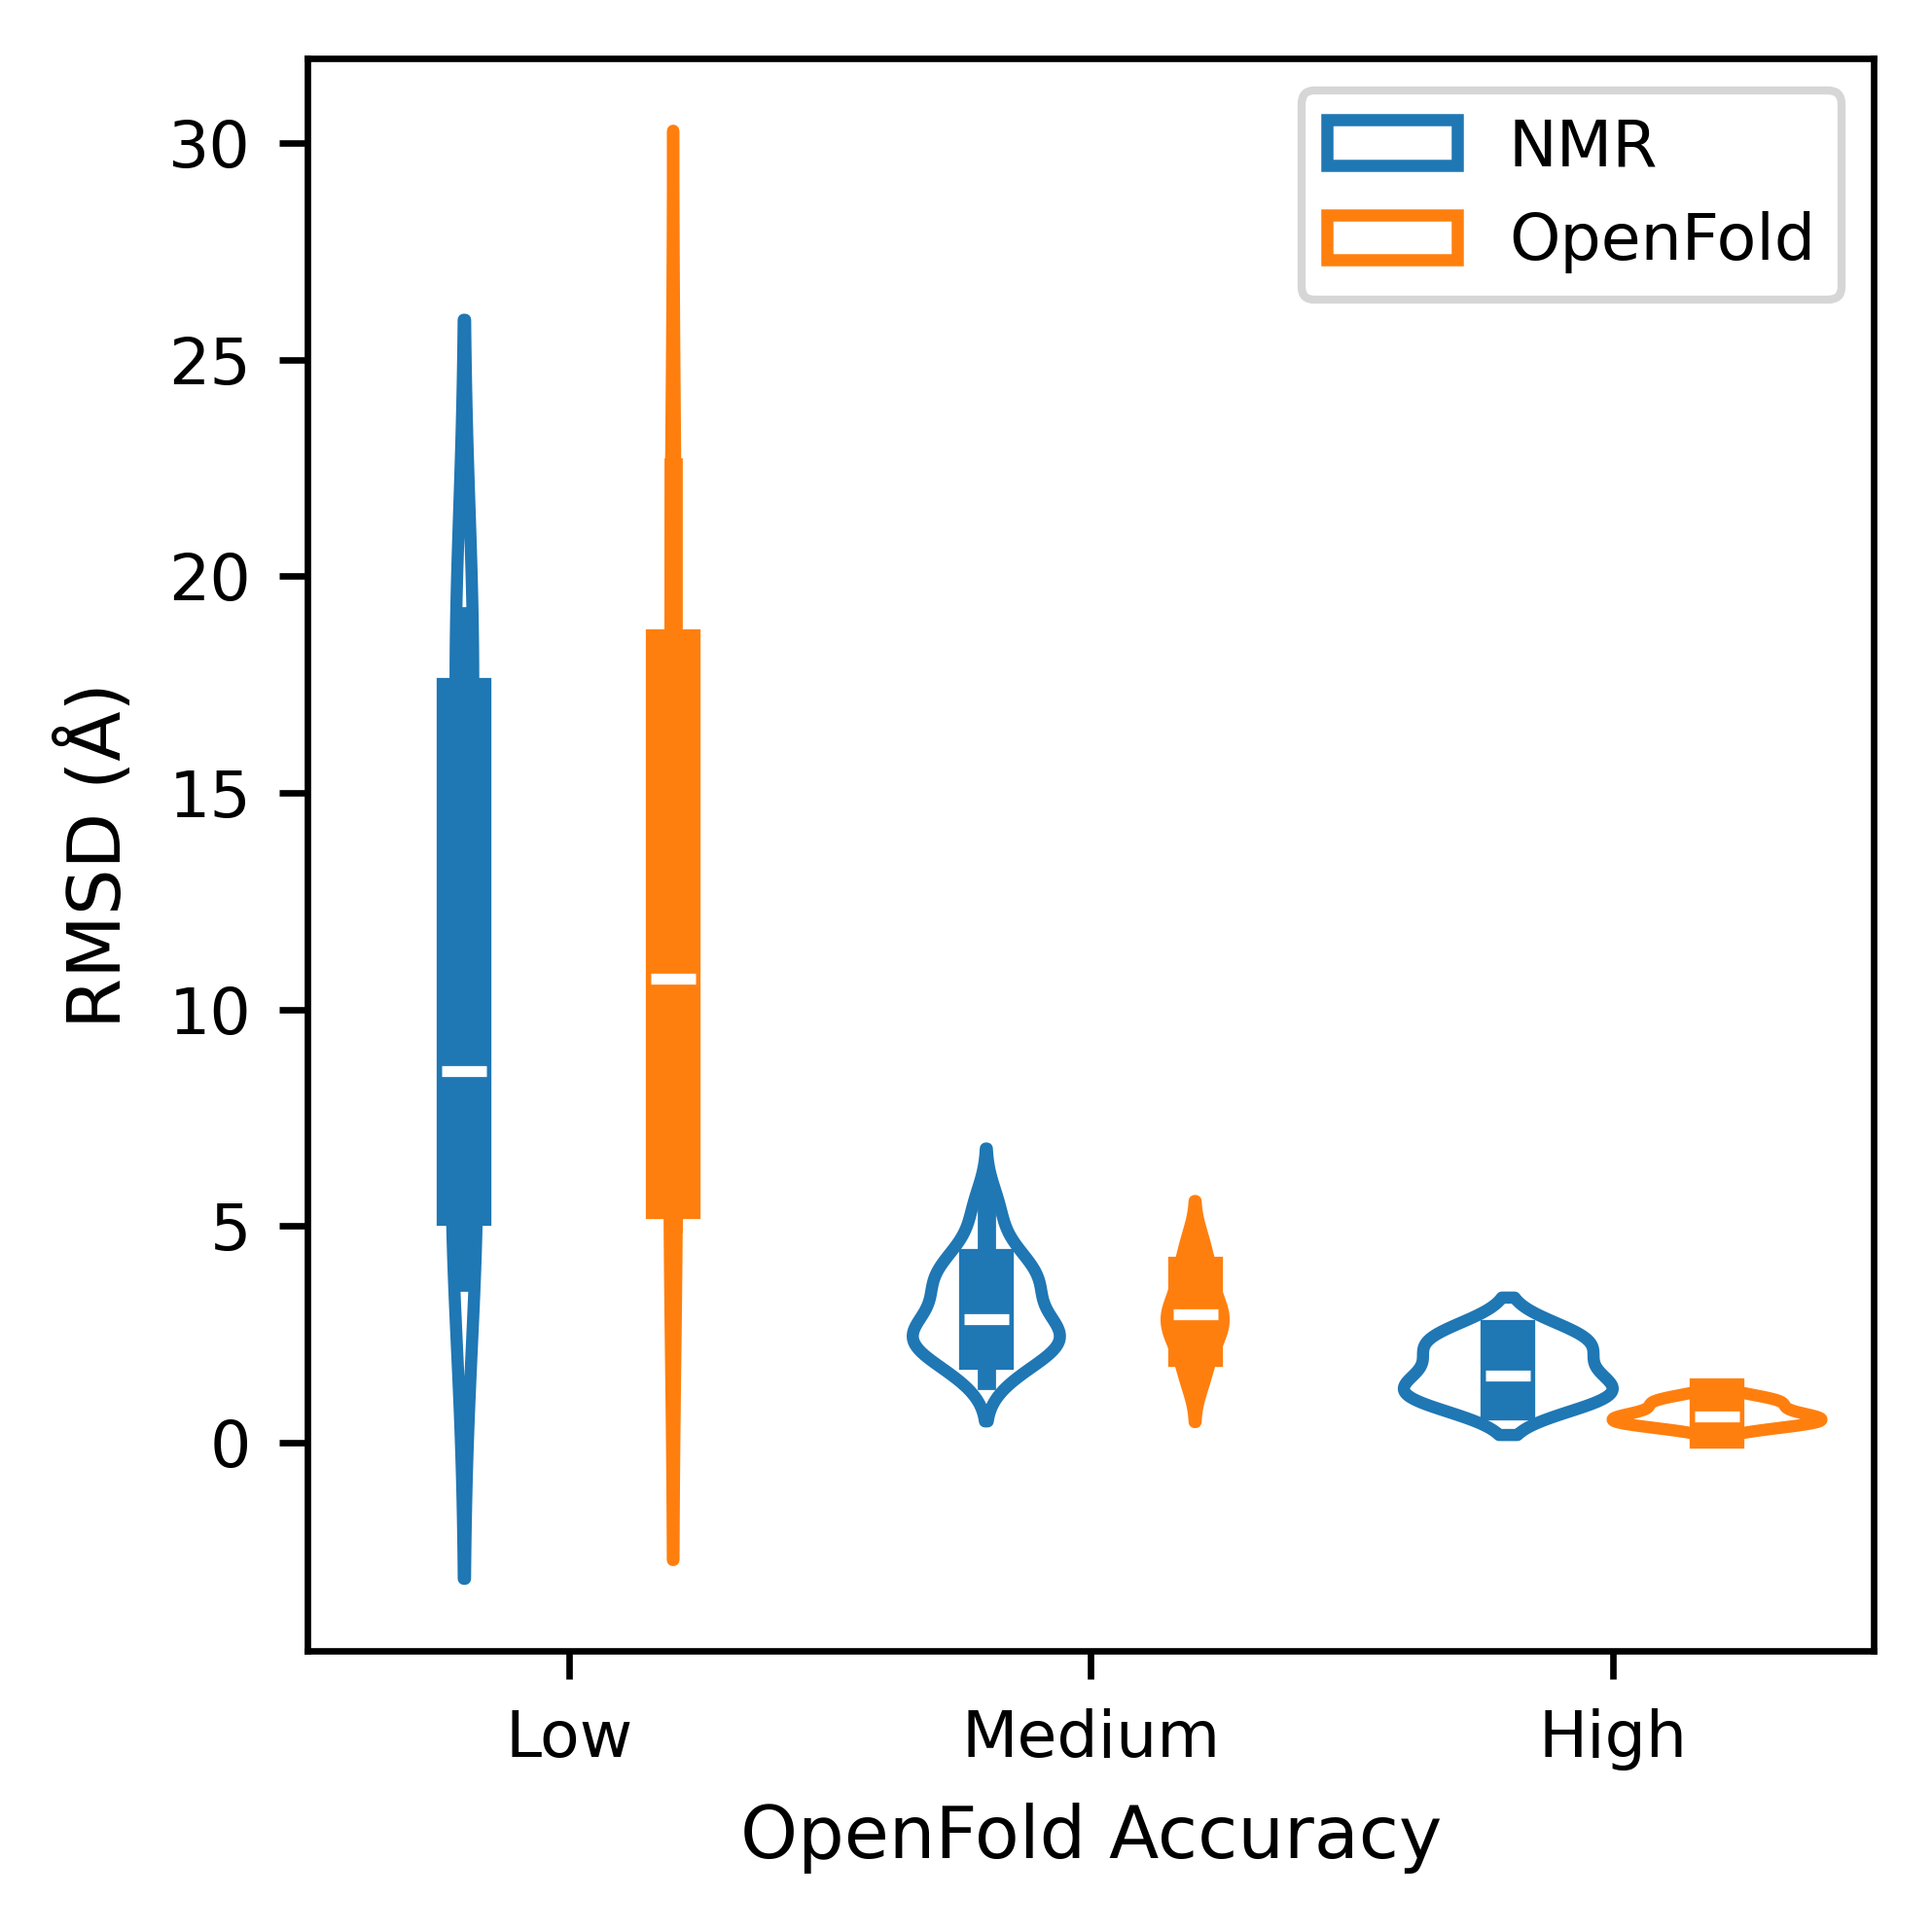

In [19]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600) # Single-column, high-res

sns.violinplot( y='rmsd',x='OpenFold Accuracy',hue='type',fill=False, data=plot_rmsd, ax=ax)
ax.set_xlabel('OpenFold Accuracy', labelpad=4)
ax.set_ylabel('RMSD (Å)', labelpad=4)
#ax.set_title('Violin Plot Example', fontsize=9, pad=8)

# Remove legend if it just duplicates x info, or set title to None
legend = ax.get_legend()
if legend:
    legend.set_title(None)

plt.tight_layout()
plt.savefig('RMSD comparison')

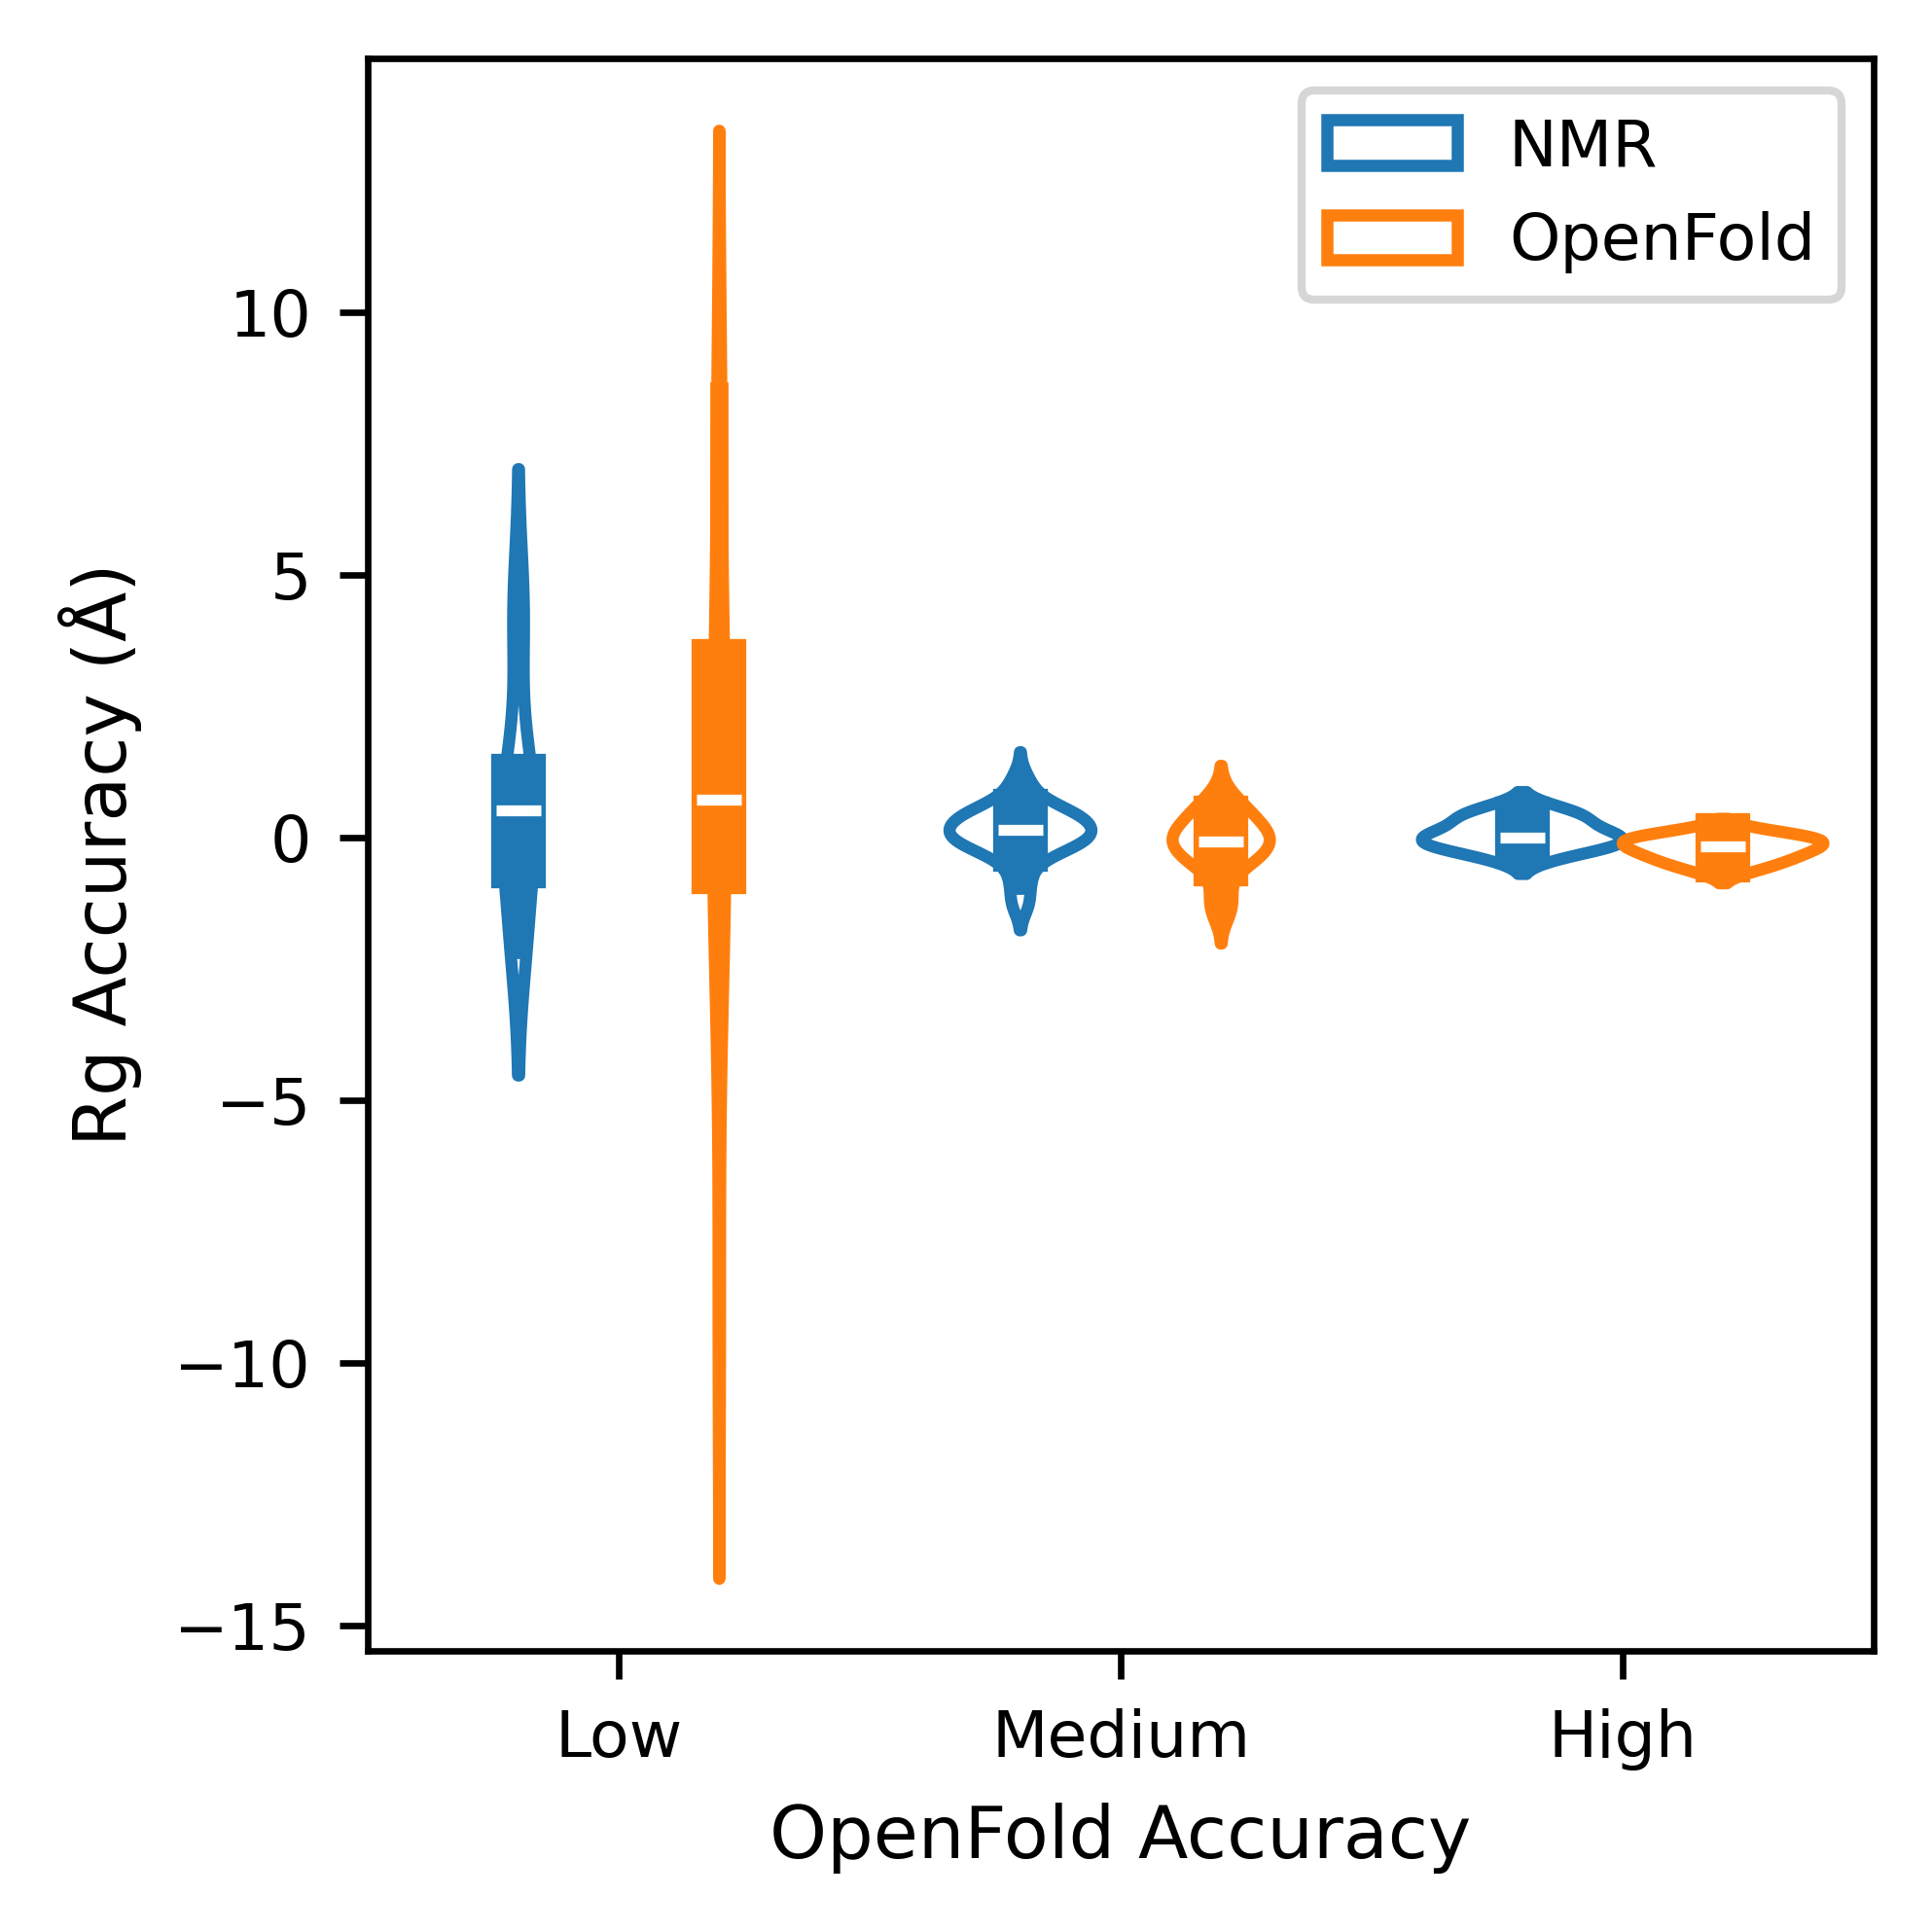

In [20]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600) # Single-column, high-res

sns.violinplot( y='rg_diff_A',x='OpenFold Accuracy',hue='type',fill=False, data=plot_rmsd, ax=ax)
ax.set_xlabel('OpenFold Accuracy', labelpad=4)
ax.set_ylabel('Rg Accuracy (Å)', labelpad=4)
#ax.set_title('Violin Plot Example', fontsize=9, pad=8)

# Remove legend if it just duplicates x info, or set title to None
legend = ax.get_legend()
if legend:
    legend.set_title(None)

plt.tight_layout()
plt.savefig('Rg comparison')

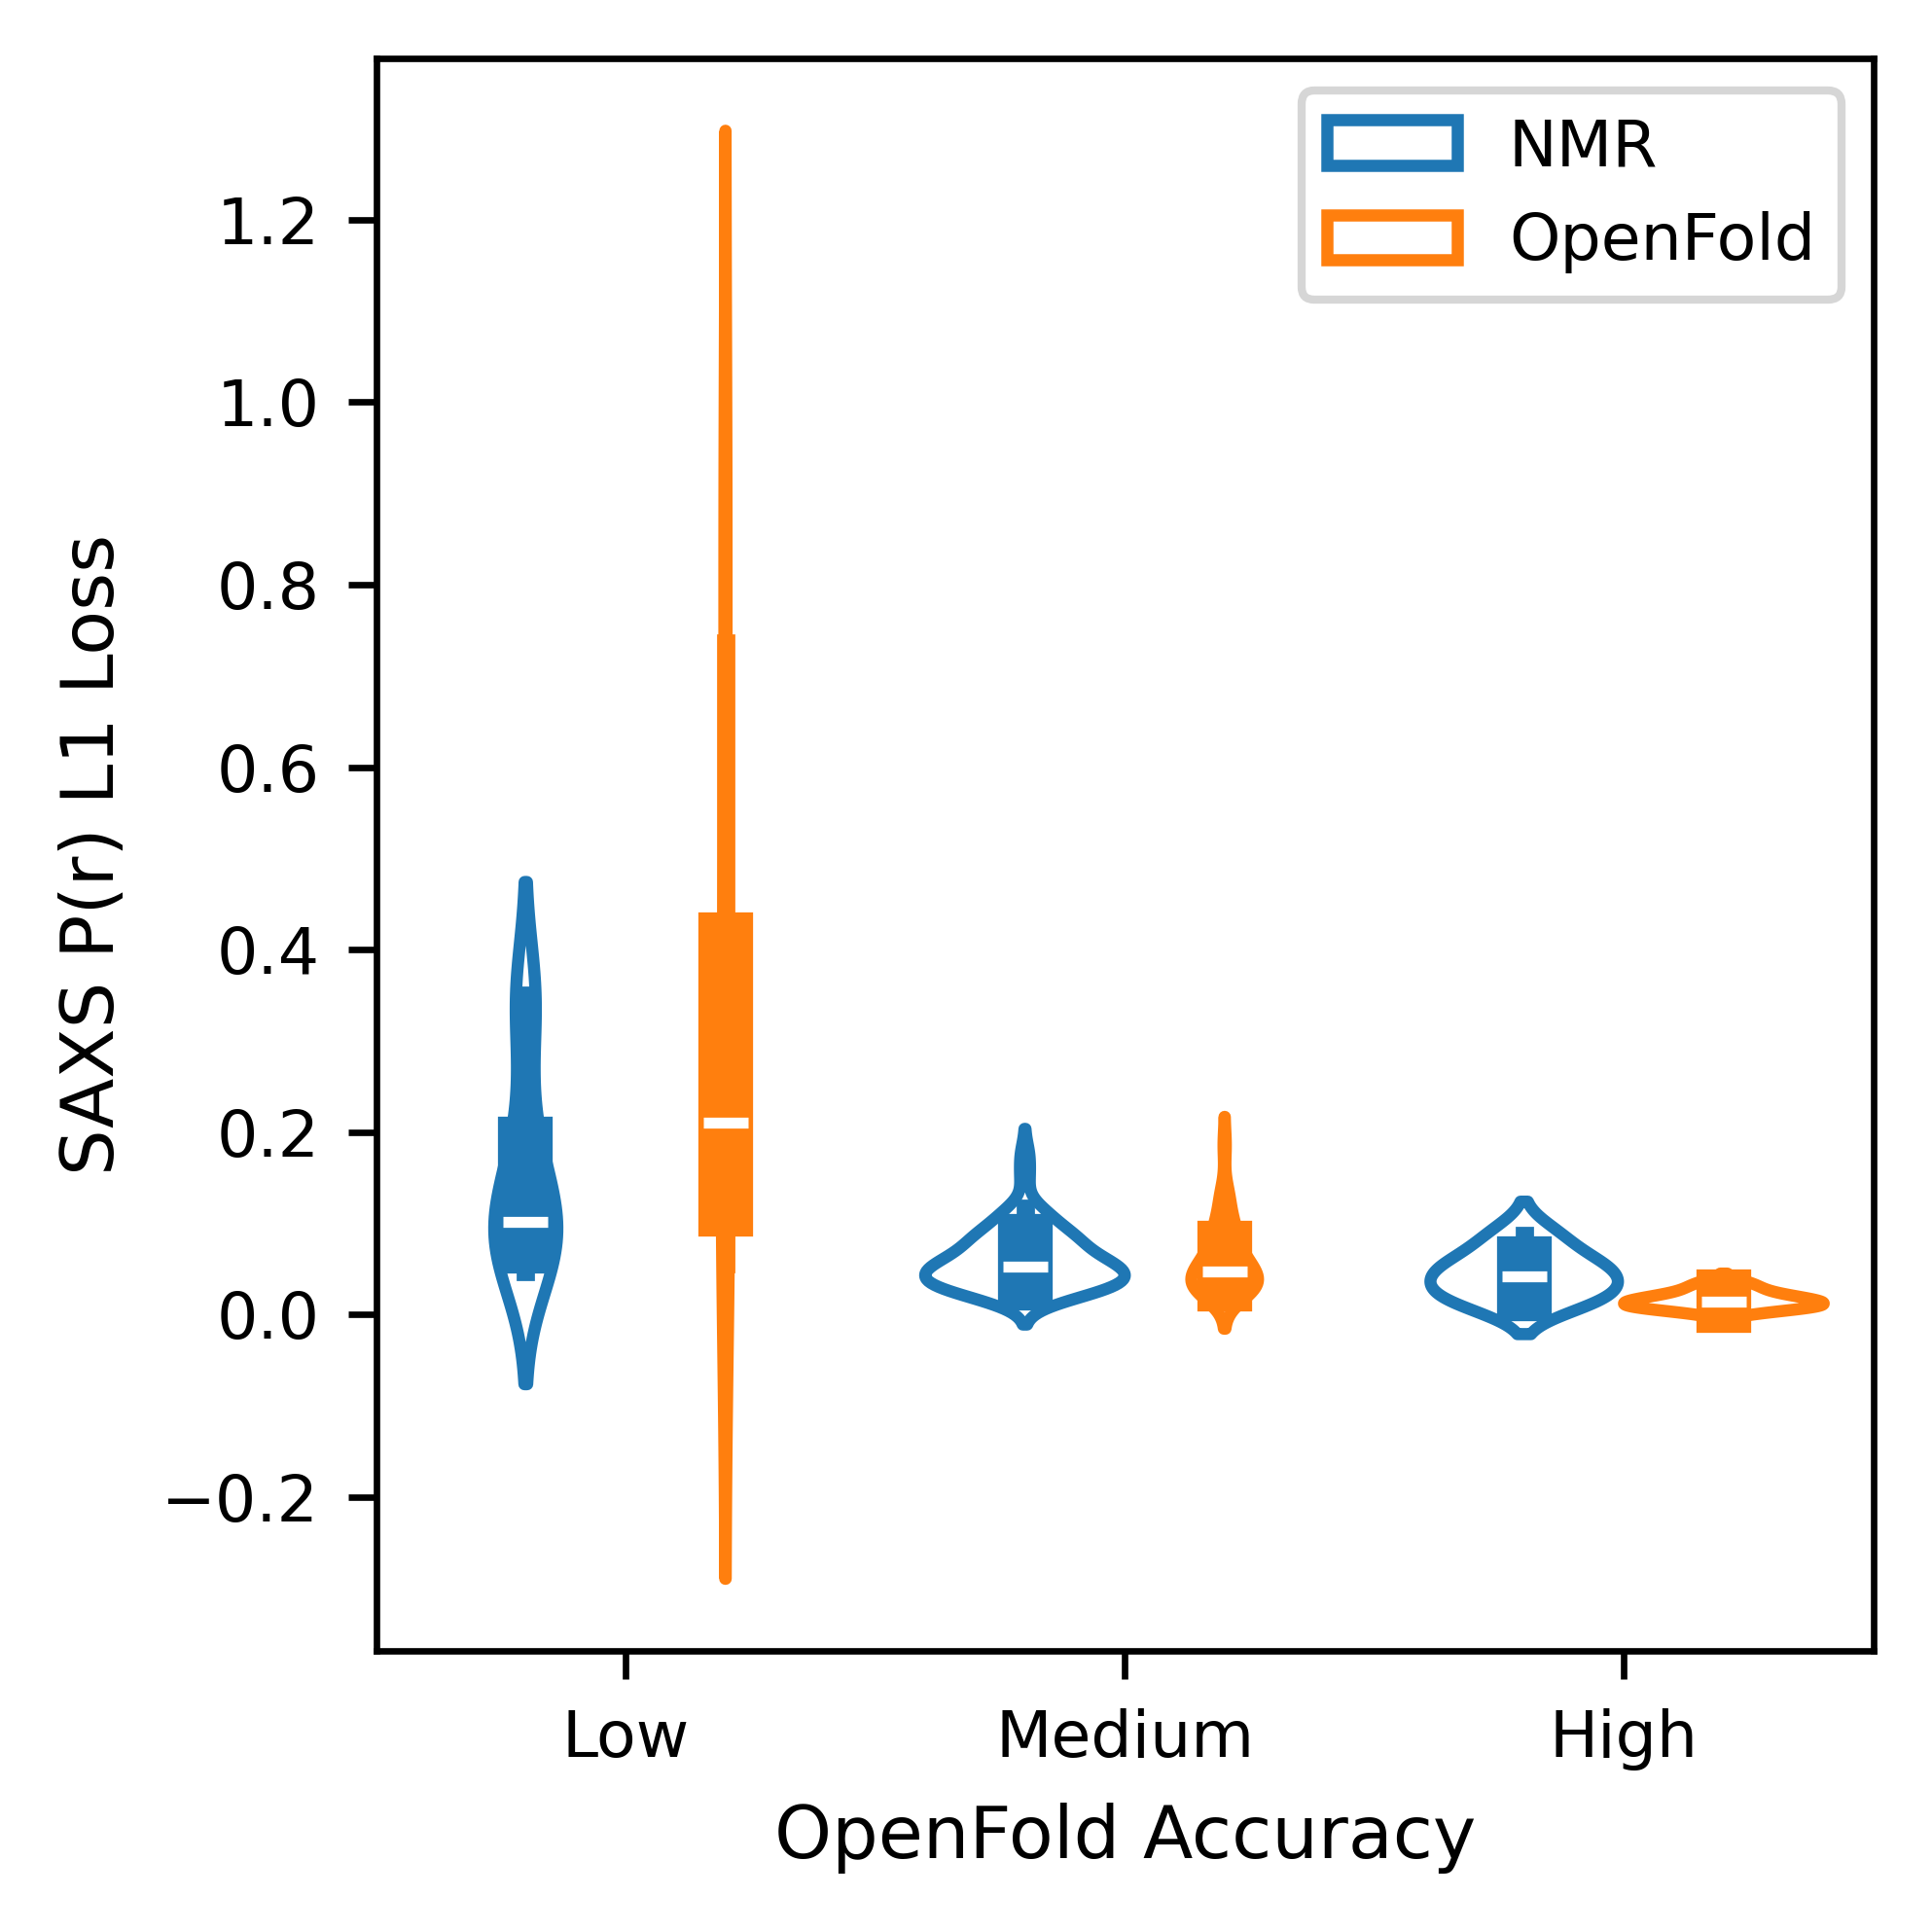

In [21]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600) # Single-column, high-res

sns.violinplot( y='saxs_l1',x='OpenFold Accuracy',hue='type',fill=False, data=plot_rmsd, ax=ax)
ax.set_xlabel('OpenFold Accuracy', labelpad=4)
ax.set_ylabel('SAXS P(r) L1 Loss', labelpad=4)
#ax.set_title('Violin Plot Example', fontsize=9, pad=8)

# Remove legend if it just duplicates x info, or set title to None
legend = ax.get_legend()
if legend:
    legend.set_title(None)

plt.tight_layout()
#plt.semilogy()
plt.savefig('L1 Loss comparison.png')

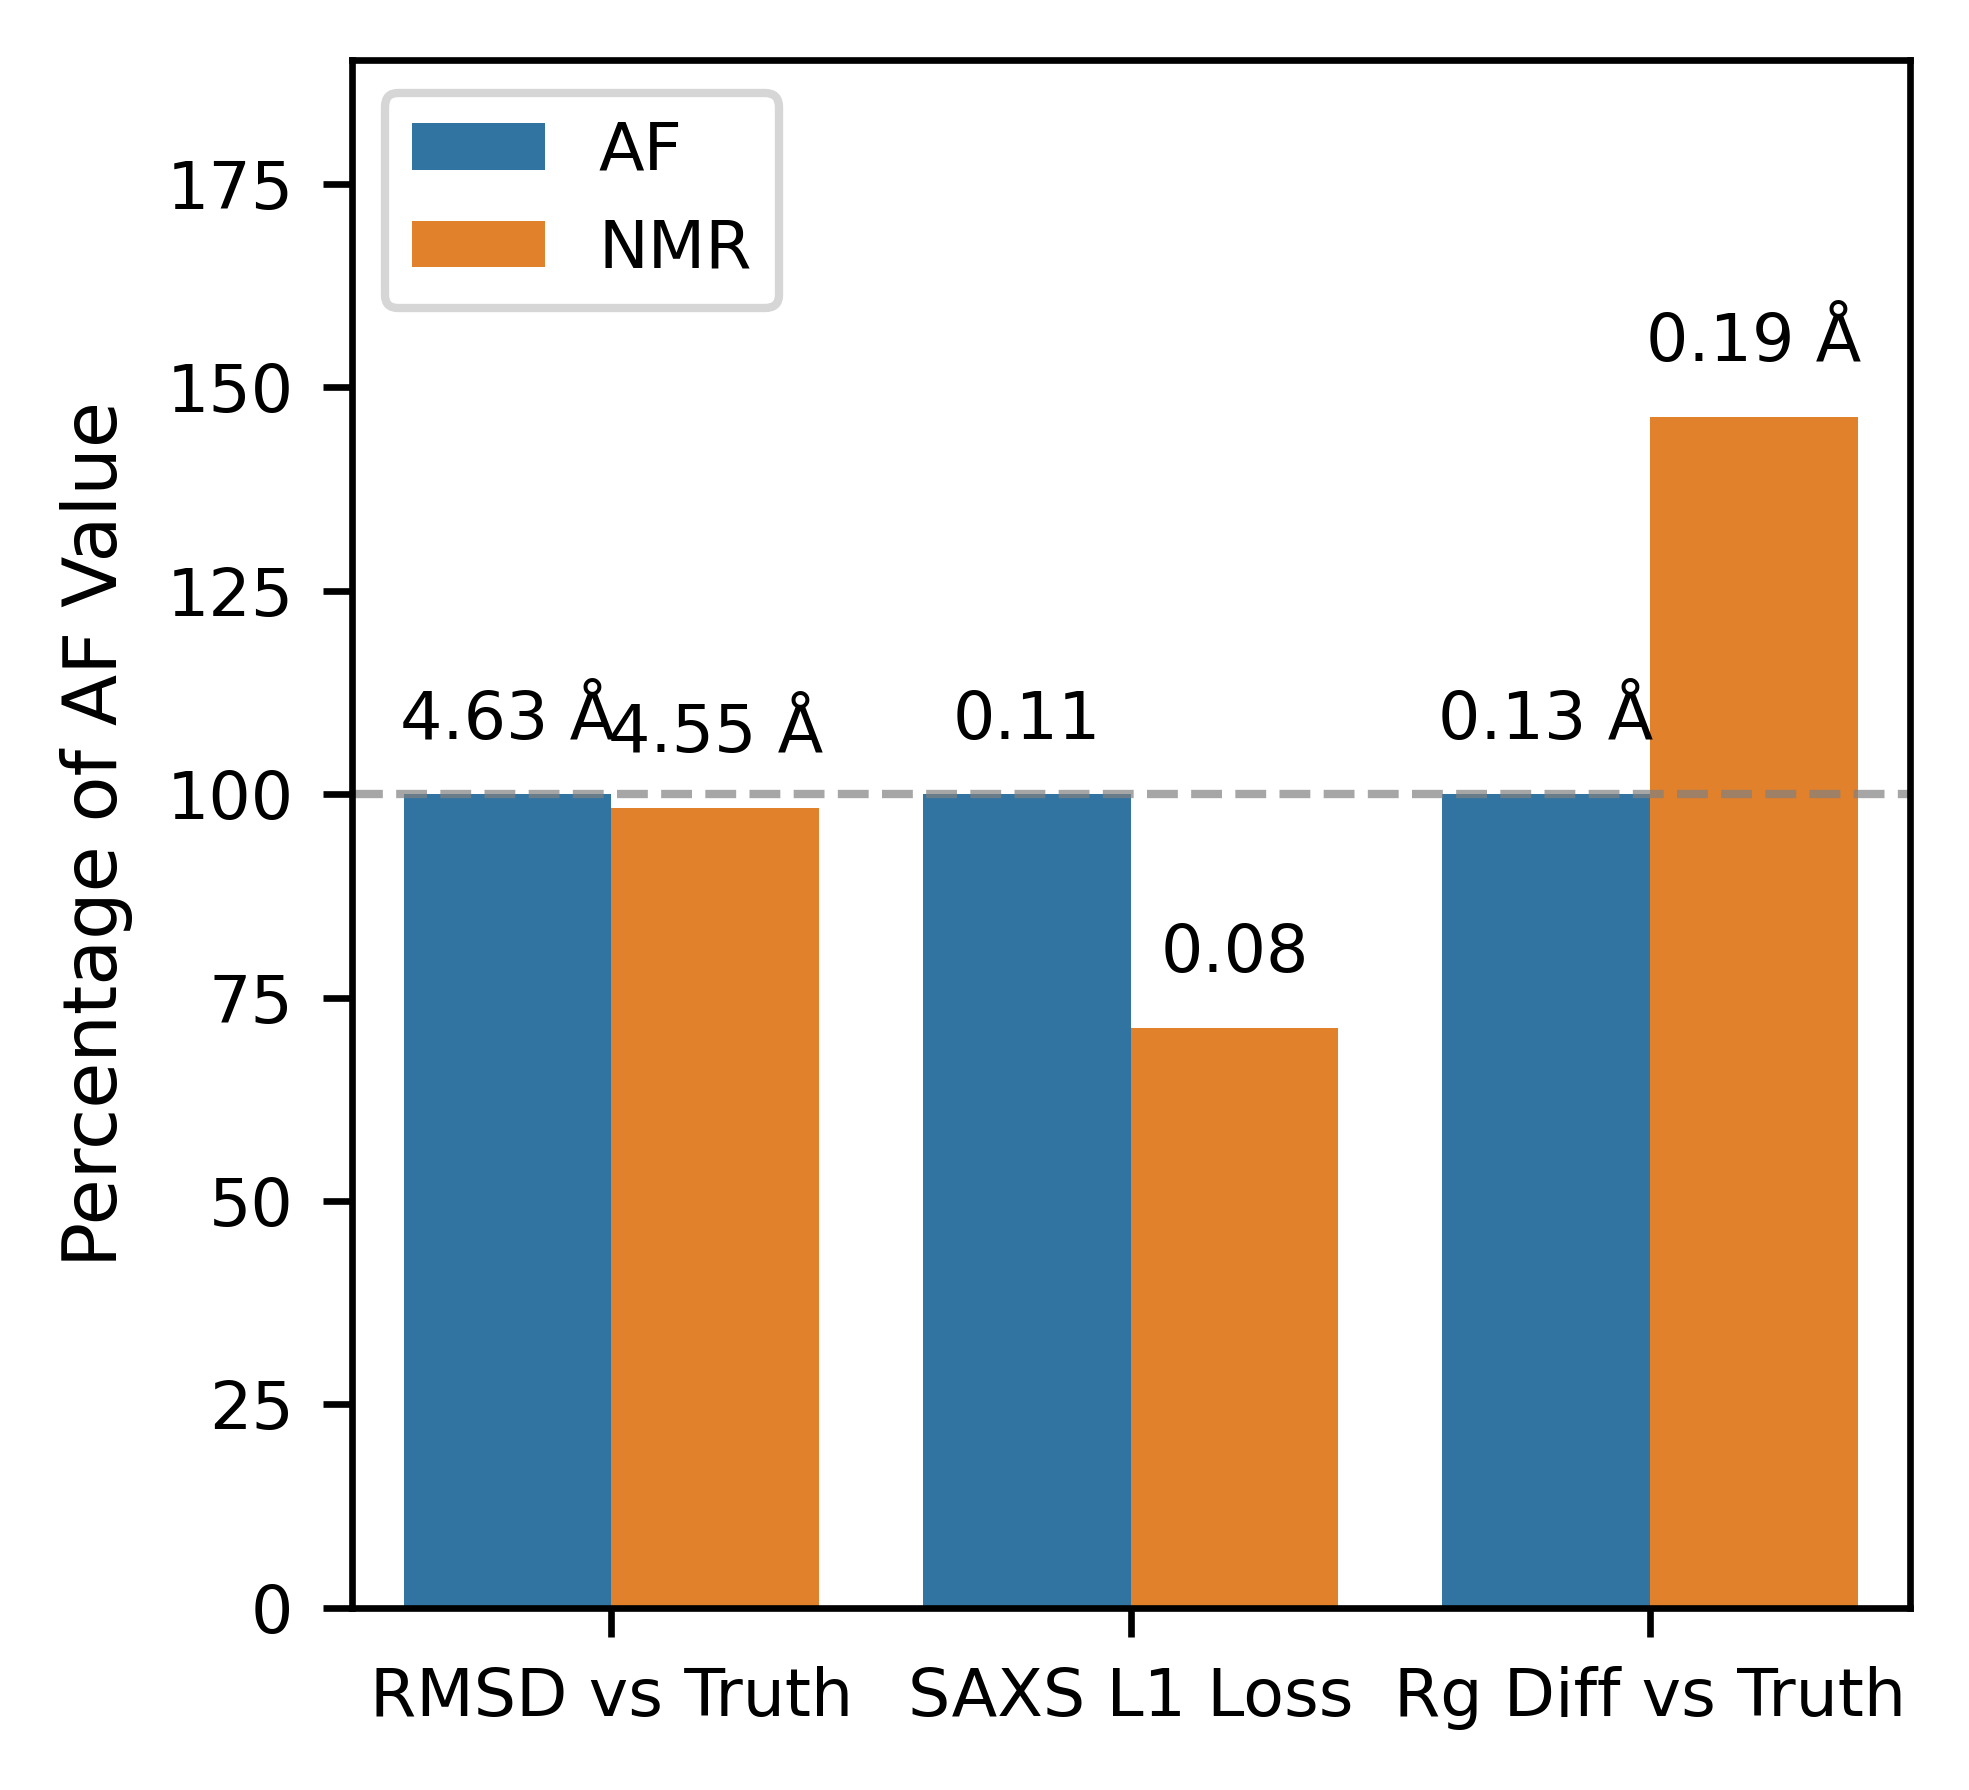

In [23]:
NMR_RMSD = NMR_result.merge(AF_result, on='name', suffixes=['', 'y'])[['name', 'rmsd', 'saxs_l1', 'rg_diff_A', 'type', 'OpenFold Accuracy']]
AF_RMSD = AF_result[['name', 'rmsd', 'saxs_l1', 'rg_diff_A', 'type', 'OpenFold Accuracy']]

# 1. Add Source Label & Combine
NMR_RMSD['Source'] = 'NMR'
AF_RMSD['Source'] = 'AF'
combined_df = pd.concat([NMR_RMSD, AF_RMSD])

metric_rename_map = {
    'rmsd': 'RMSD vs Truth',
    'saxs_l1': 'SAXS L1 Loss',
    'rg_diff_A': 'Rg Diff vs Truth'
}

# 2. Normalize and Prepare Data (Long Format)
# Calculate means if not already done
metrics = ['rmsd', 'saxs_l1', 'rg_diff_A']
means = combined_df.groupby('Source')[metrics].mean().reset_index()

# Get AF Baselines
af_means = means[means['Source'] == 'AF'].set_index('Source')
af_vals = {m: af_means.loc['AF', m] for m in metrics}

# Melt to long format
means_long = means.melt(id_vars='Source', value_vars=metrics, 
                        var_name='Metric', value_name='Absolute_Value')

# Add Display Name Column
means_long['Metric_Label'] = means_long['Metric'].map(metric_rename_map)

# Calculate Percentage (AF = 100%)
def calculate_pct(row):
    metric = row['Metric']
    base_val = af_vals.get(metric, 1)
    return (row['Absolute_Value'] / base_val) * 100

means_long['Percentage'] = means_long.apply(calculate_pct, axis=1)

# Calculate Difference (NMR - AF)
def calculate_diff(row):
    if row['Source'] == 'AF': return 0.0
    metric = row['Metric']
    base_val = af_vals.get(metric, 0)
    return row['Absolute_Value'] - base_val

means_long['Diff'] = means_long.apply(calculate_diff, axis=1)

# 3. Plotting
# Use existing rcParams (no plt.rcParams.update calls here)
plt.figure(figsize=(3.35, 3.35), dpi=600)

hue_order = ['AF', 'NMR']
x_order = ['RMSD vs Truth', 'SAXS L1 Loss', 'Rg Diff vs Truth']

ax = sns.barplot(data=means_long, x='Metric_Label', y='Percentage', hue='Source', 
                 hue_order=hue_order, order=x_order)

plt.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# 4. Annotations with Units (Angstrom)
unit_map = {
    'RMSD vs Truth': 'Å',
    'Rg Diff vs Truth': 'Å',
    'SAXS L1 Loss': ''
}

labels_data = []
for hue in hue_order:
    for label_name in x_order:
        row = means_long[(means_long['Source'] == hue) & (means_long['Metric_Label'] == label_name)].iloc[0]
        abs_val = row['Absolute_Value']
        diff = row['Diff']
        unit = unit_map.get(label_name, '')
        unit_str = f" {unit}" if unit else ""
        
        if hue == 'AF':
            label = f"{abs_val:.2f}{unit_str}"
        else:
            sign = "+" if diff > 0 else ""
            label = f"{abs_val:.2f}{unit_str}"
        labels_data.append(label)

# Apply annotations
for i, p in enumerate(ax.patches):
    if i < len(labels_data):
        ax.annotate(labels_data[i], 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', color='black', 
                    xytext=(0, 5), textcoords='offset points')

plt.xlabel('') # Clean x-axis label
plt.ylabel('Percentage of AF Value')
plt.ylim(0, means_long['Percentage'].max() * 1.3)
plt.legend(loc='upper left')
plt.savefig('final_renamed_barplot.png')

In [24]:
ref_result=result[(result['type_a']=='target')&(result['type_b']=='target_alt')]
ref_result['rg_diff_A']=ref_result['rg_diff']*10

/tmp/ipykernel_405725/3381075510.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ref_result['rg_diff_A']=ref_result['rg_diff']*10


In [25]:
ref_result_pair=ref_result[ref_result['name'].isin(apo_ids)][['name','name_alt','rmsd','saxs_l1']]

In [26]:
NMR_result_pair=result[(result['type_a']=='out_NMR')&(result['type_b']=='out_alt_NMR')]

In [27]:
NMR_result_pair=NMR_result_pair[NMR_result_pair['name'].isin(apo_ids)][['name','name_alt','rmsd','saxs_l1']]

In [28]:
AF_result_pair=result[(result['type_a']=='out_AF')&(result['type_b']=='out_alt_AF')]

In [29]:
AF_result_pair=AF_result_pair[AF_result_pair['name'].isin(apo_ids)][['name','name_alt','rmsd','saxs_l1']]

In [30]:
NMR_result_pair=NMR_result_pair.merge(ref_result_pair, on='name',suffixes=('','_ref'))[['name','name_alt','rmsd','saxs_l1','rmsd_ref','saxs_l1_ref']]

In [31]:
AF_result_pair=AF_result_pair.merge(ref_result_pair, on='name',suffixes=('','_ref'))[['name','name_alt','rmsd','saxs_l1','rmsd_ref','saxs_l1_ref']]

In [32]:
AF_result_pair['model']='OpenFold'
NMR_result_pair['model']='AlphaSAXS'
plot_result=pd.concat([NMR_result_pair,AF_result_pair])

/tmp/ipykernel_405725/319979743.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_xticklabels)


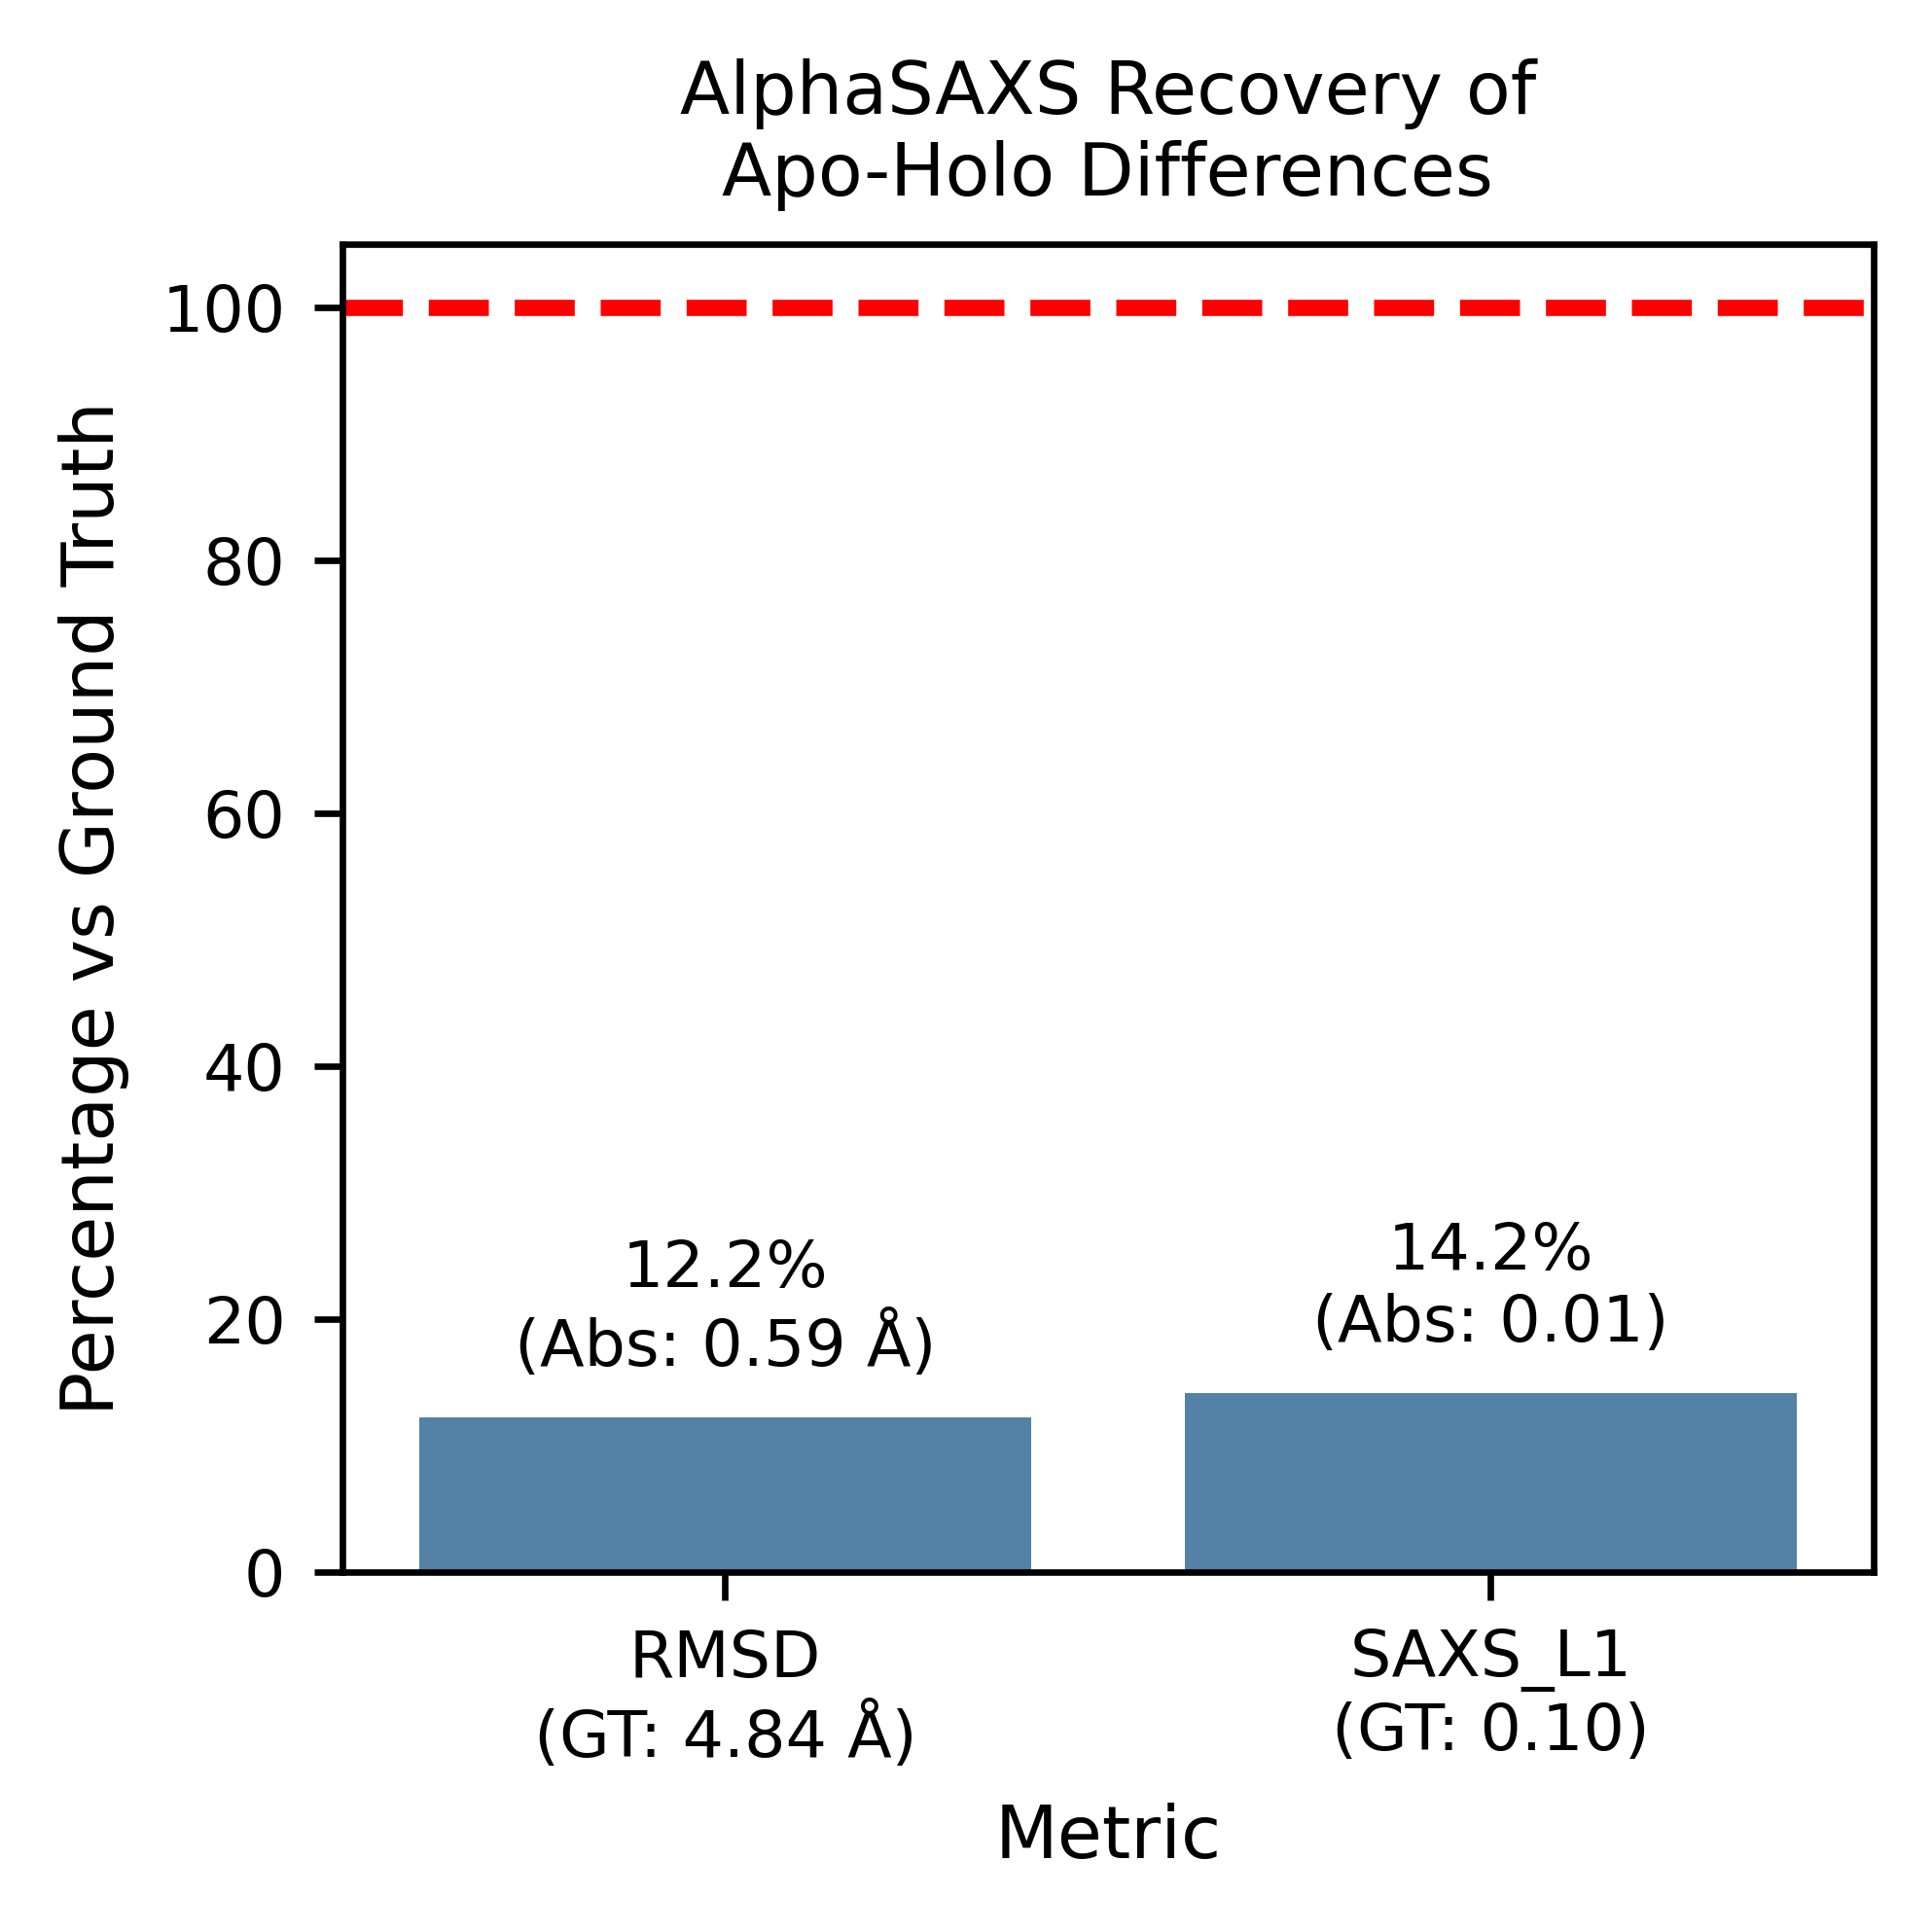

In [54]:
# --- 1. Calculate Averages ---
model_means = NMR_result_pair[['rmsd', 'saxs_l1']].mean()
ref_means = NMR_result_pair[['rmsd_ref', 'saxs_l1_ref']].mean()

# --- 2. Calculate Percentage relative to Ground Truth (Reference) ---
rmsd_pct = (model_means['rmsd'] / ref_means['rmsd_ref']) * 100
saxs_pct = (model_means['saxs_l1'] / ref_means['saxs_l1_ref']) * 100

# Create a DataFrame for plotting
plot_df = pd.DataFrame([
    {
        'Metric': 'RMSD', 
        'Percentage': rmsd_pct, 
        'Absolute': model_means['rmsd'], 
        'Ref_Absolute': ref_means['rmsd_ref']
    },
    {
        'Metric': 'SAXS_L1', 
        'Percentage': saxs_pct, 
        'Absolute': model_means['saxs_l1'], 
        'Ref_Absolute': ref_means['saxs_l1_ref']
    }
])

# --- 3. Plot ---
plt.figure(figsize=(3.35, 3.35), dpi=600)

# Bar plot
ax = sns.barplot(data=plot_df, x='Metric', y='Percentage', color='steelblue')

# Custom Annotations: Percentage + (Absolute Value + Unit)
for i, (idx, row) in enumerate(plot_df.iterrows()):
    # Add Unit only if Metric is RMSD
    unit = " Å" if row['Metric'] == 'RMSD' else ""
    
    # Format label: "85.2%\n(Abs: 3.12 Å)"
    label = f"{row['Percentage']:.1f}%\n(Abs: {row['Absolute']:.2f}{unit})"
    
    # Get position
    bar = ax.patches[i]
    x_pos = bar.get_x() + bar.get_width() / 2
    y_pos = bar.get_height()
    
    # Add text
    ax.text(x_pos, y_pos + 3, label, ha='center', va='bottom', color='black')

# Modify X-axis labels to include Ground Truth Value
new_xticklabels = []
for _, row in plot_df.iterrows():
    unit = " Å" if row['Metric'] == 'RMSD' else ""
    # "GT" stands for Ground Truth to keep it compact
    new_xticklabels.append(f"{row['Metric']}\n(GT: {row['Ref_Absolute']:.2f}{unit})")

ax.set_xticklabels(new_xticklabels)

# Reference Line
plt.axhline(100, color='red', linestyle='--', linewidth=2, label='Ground Truth (100%)')

# --- Updated Titles and Labels ---
# Reflecting that we are measuring how much of the difference was "uncovered"
plt.title('AlphaSAXS Recovery of\nApo-Holo Differences')
plt.ylabel('Percentage vs Ground Truth')

#plt.ylim(0, plot_df['Percentage'].max() * 1.45) 
plt.tight_layout()

plt.savefig('alphasaxs_ground_truth_recovery.png')
plt.show()

In [34]:
conditions = [
    (plot_result['saxs_l1_ref'] <= 0.05),

    (plot_result['saxs_l1_ref']  > 0.05) & (plot_result['saxs_l1_ref'] <= 0.1),

    (plot_result['saxs_l1_ref']  > 0.1)
]

choices = ['High', 'Medium', 'Low']

plot_result['Apo vs Holo Similarity'] = np.select(
    conditions, 
    choices,
)

In [35]:
plot_result[plot_result['name']=='1F3Y-17_A']

,name,name_alt,rmsd,saxs_l1,rmsd_ref,saxs_l1_ref,model,Apo vs Holo Similarity
0,1F3Y-17_A,1JKN-15_A,0.522948,0.007856,5.077047,0.134375,AlphaSAXS,Low
0,1F3Y-17_A,1JKN-15_A,0.111485,0.004583,5.077047,0.134375,OpenFold,Low


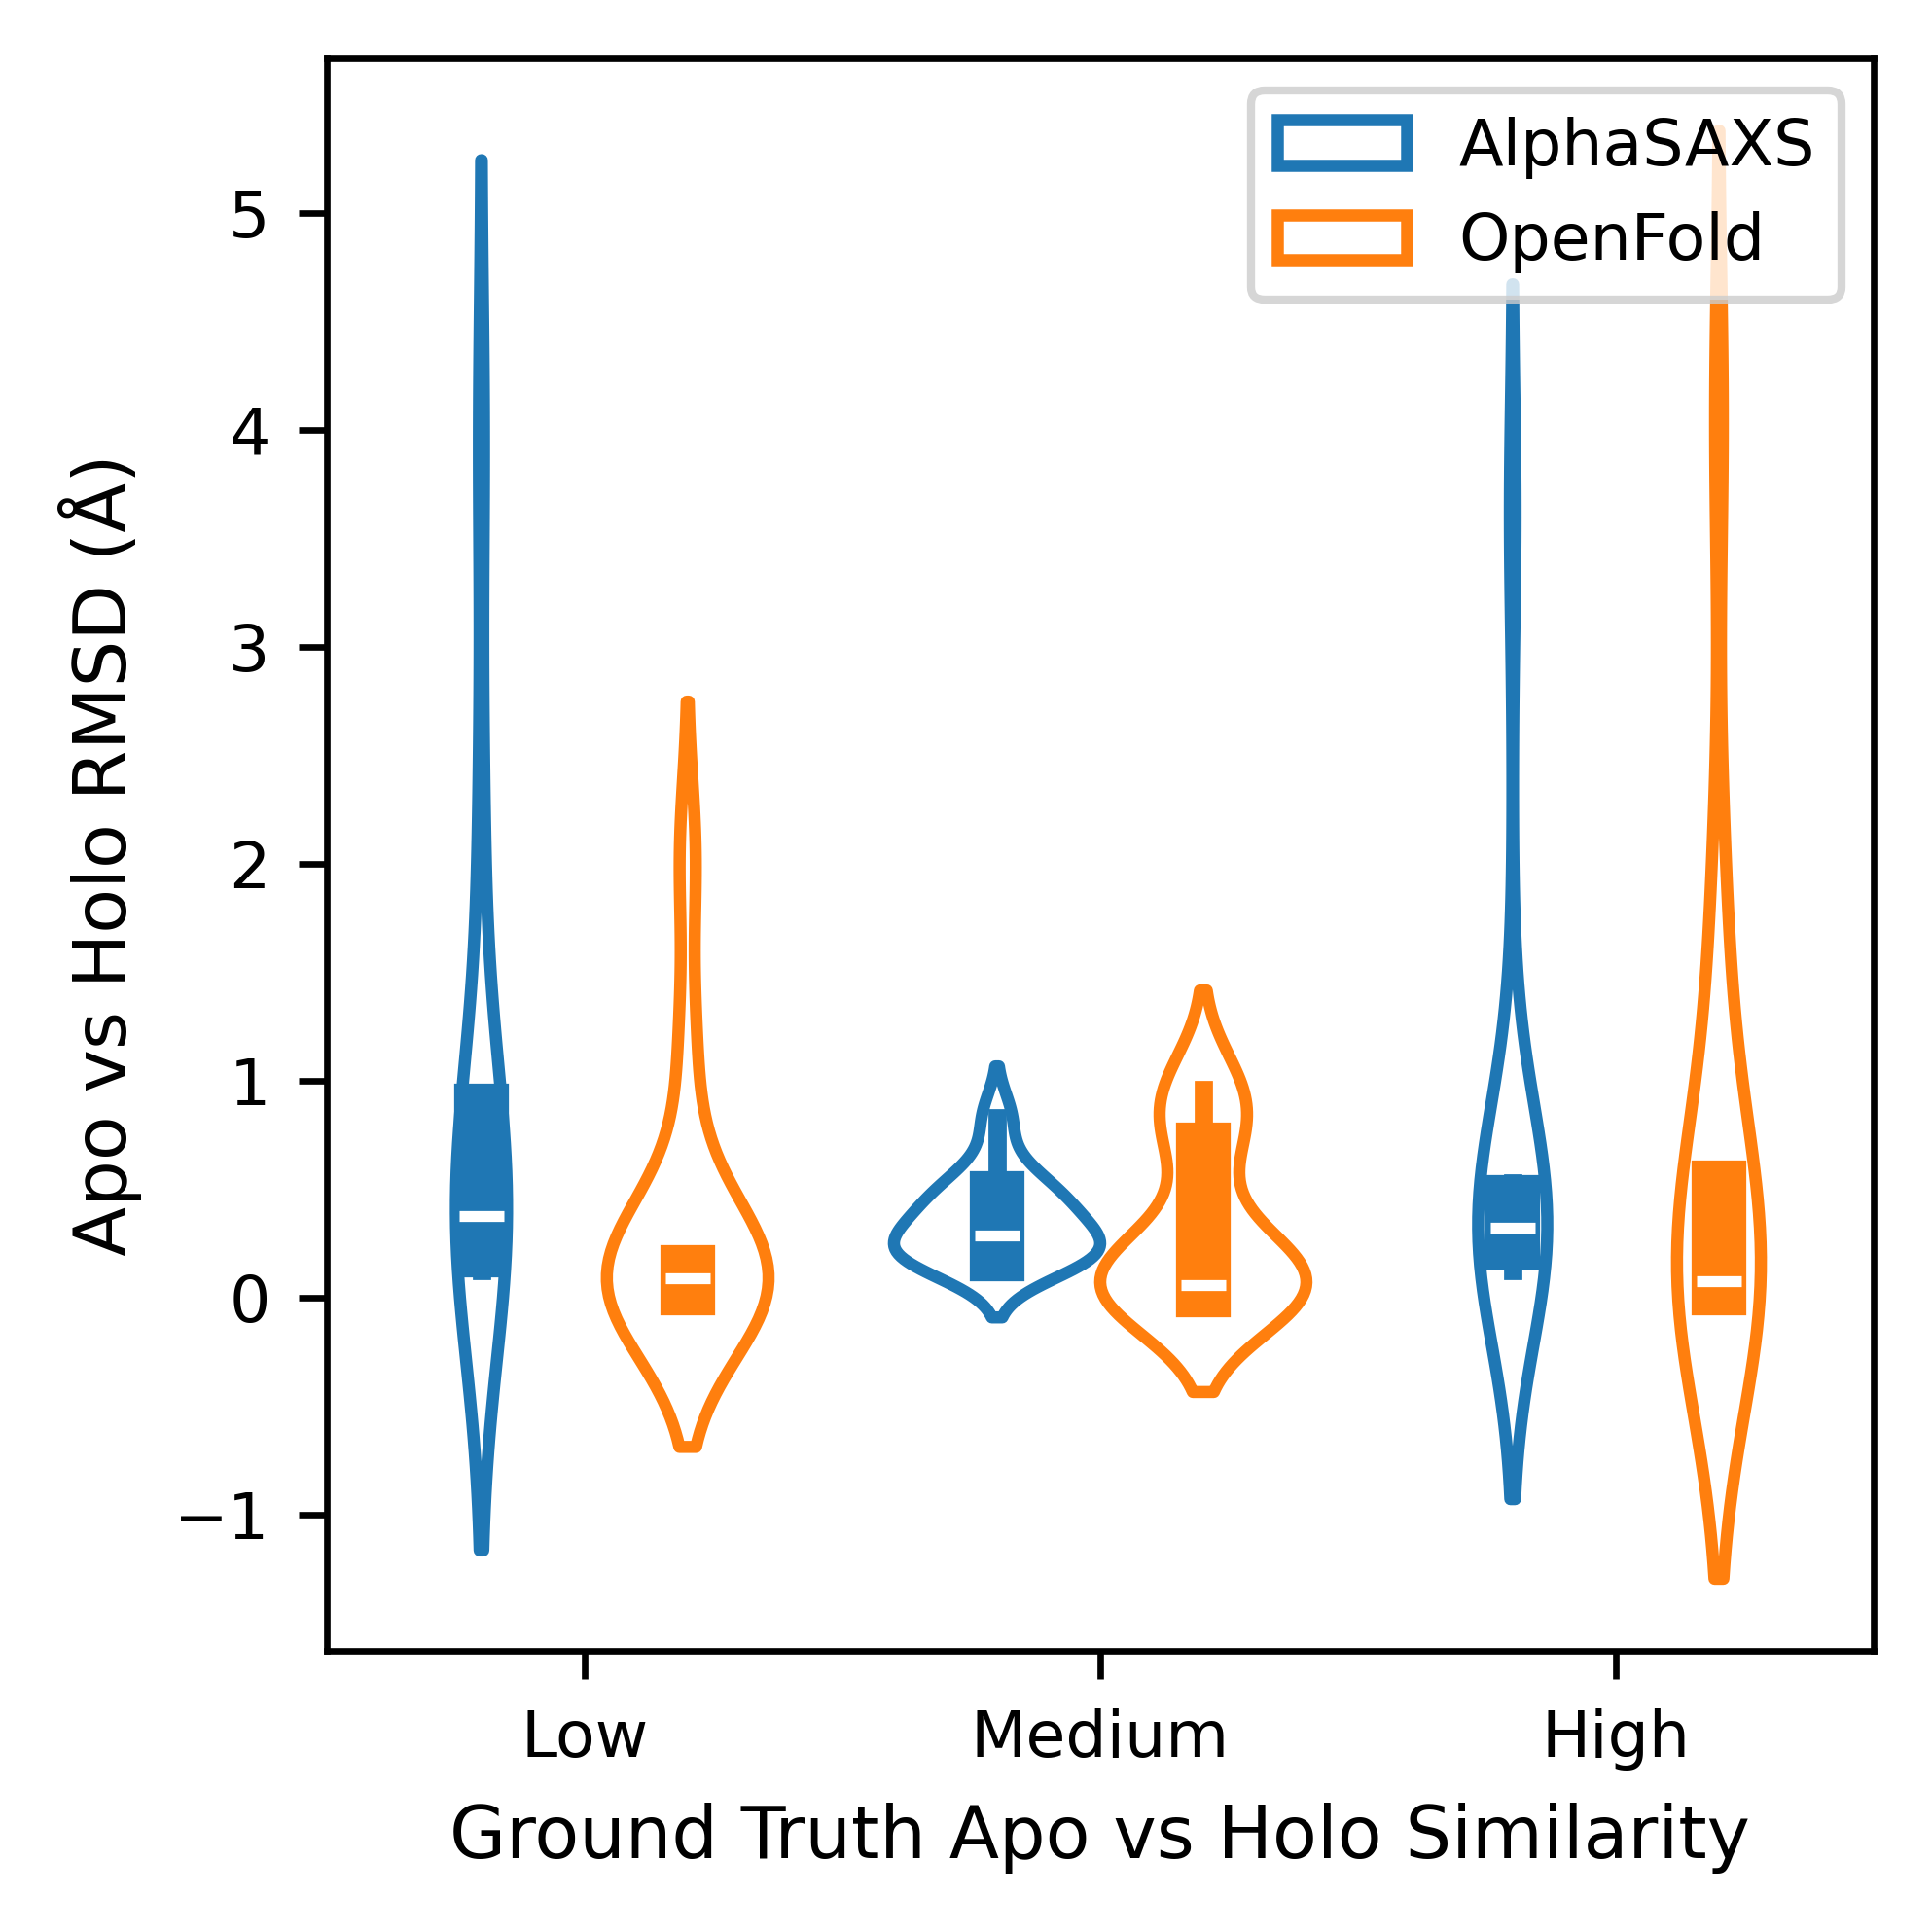

In [36]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600) # Single-column, high-res

sns.violinplot(y='rmsd',x='Apo vs Holo Similarity',hue='model',fill=False, data=plot_result, ax=ax,order=['Low', 'Medium', 'High'])
ax.set_xlabel('Ground Truth Apo vs Holo Similarity', labelpad=4)
ax.set_ylabel('Apo vs Holo RMSD (Å)', labelpad=4)
#ax.set_title('Violin Plot Example', fontsize=9, pad=8)

# Remove legend if it just duplicates x info, or set title to None
legend = ax.get_legend()
if legend:
    legend.set_title(None)

plt.tight_layout()
plt.savefig('Apo_Holo_RMSD.png')

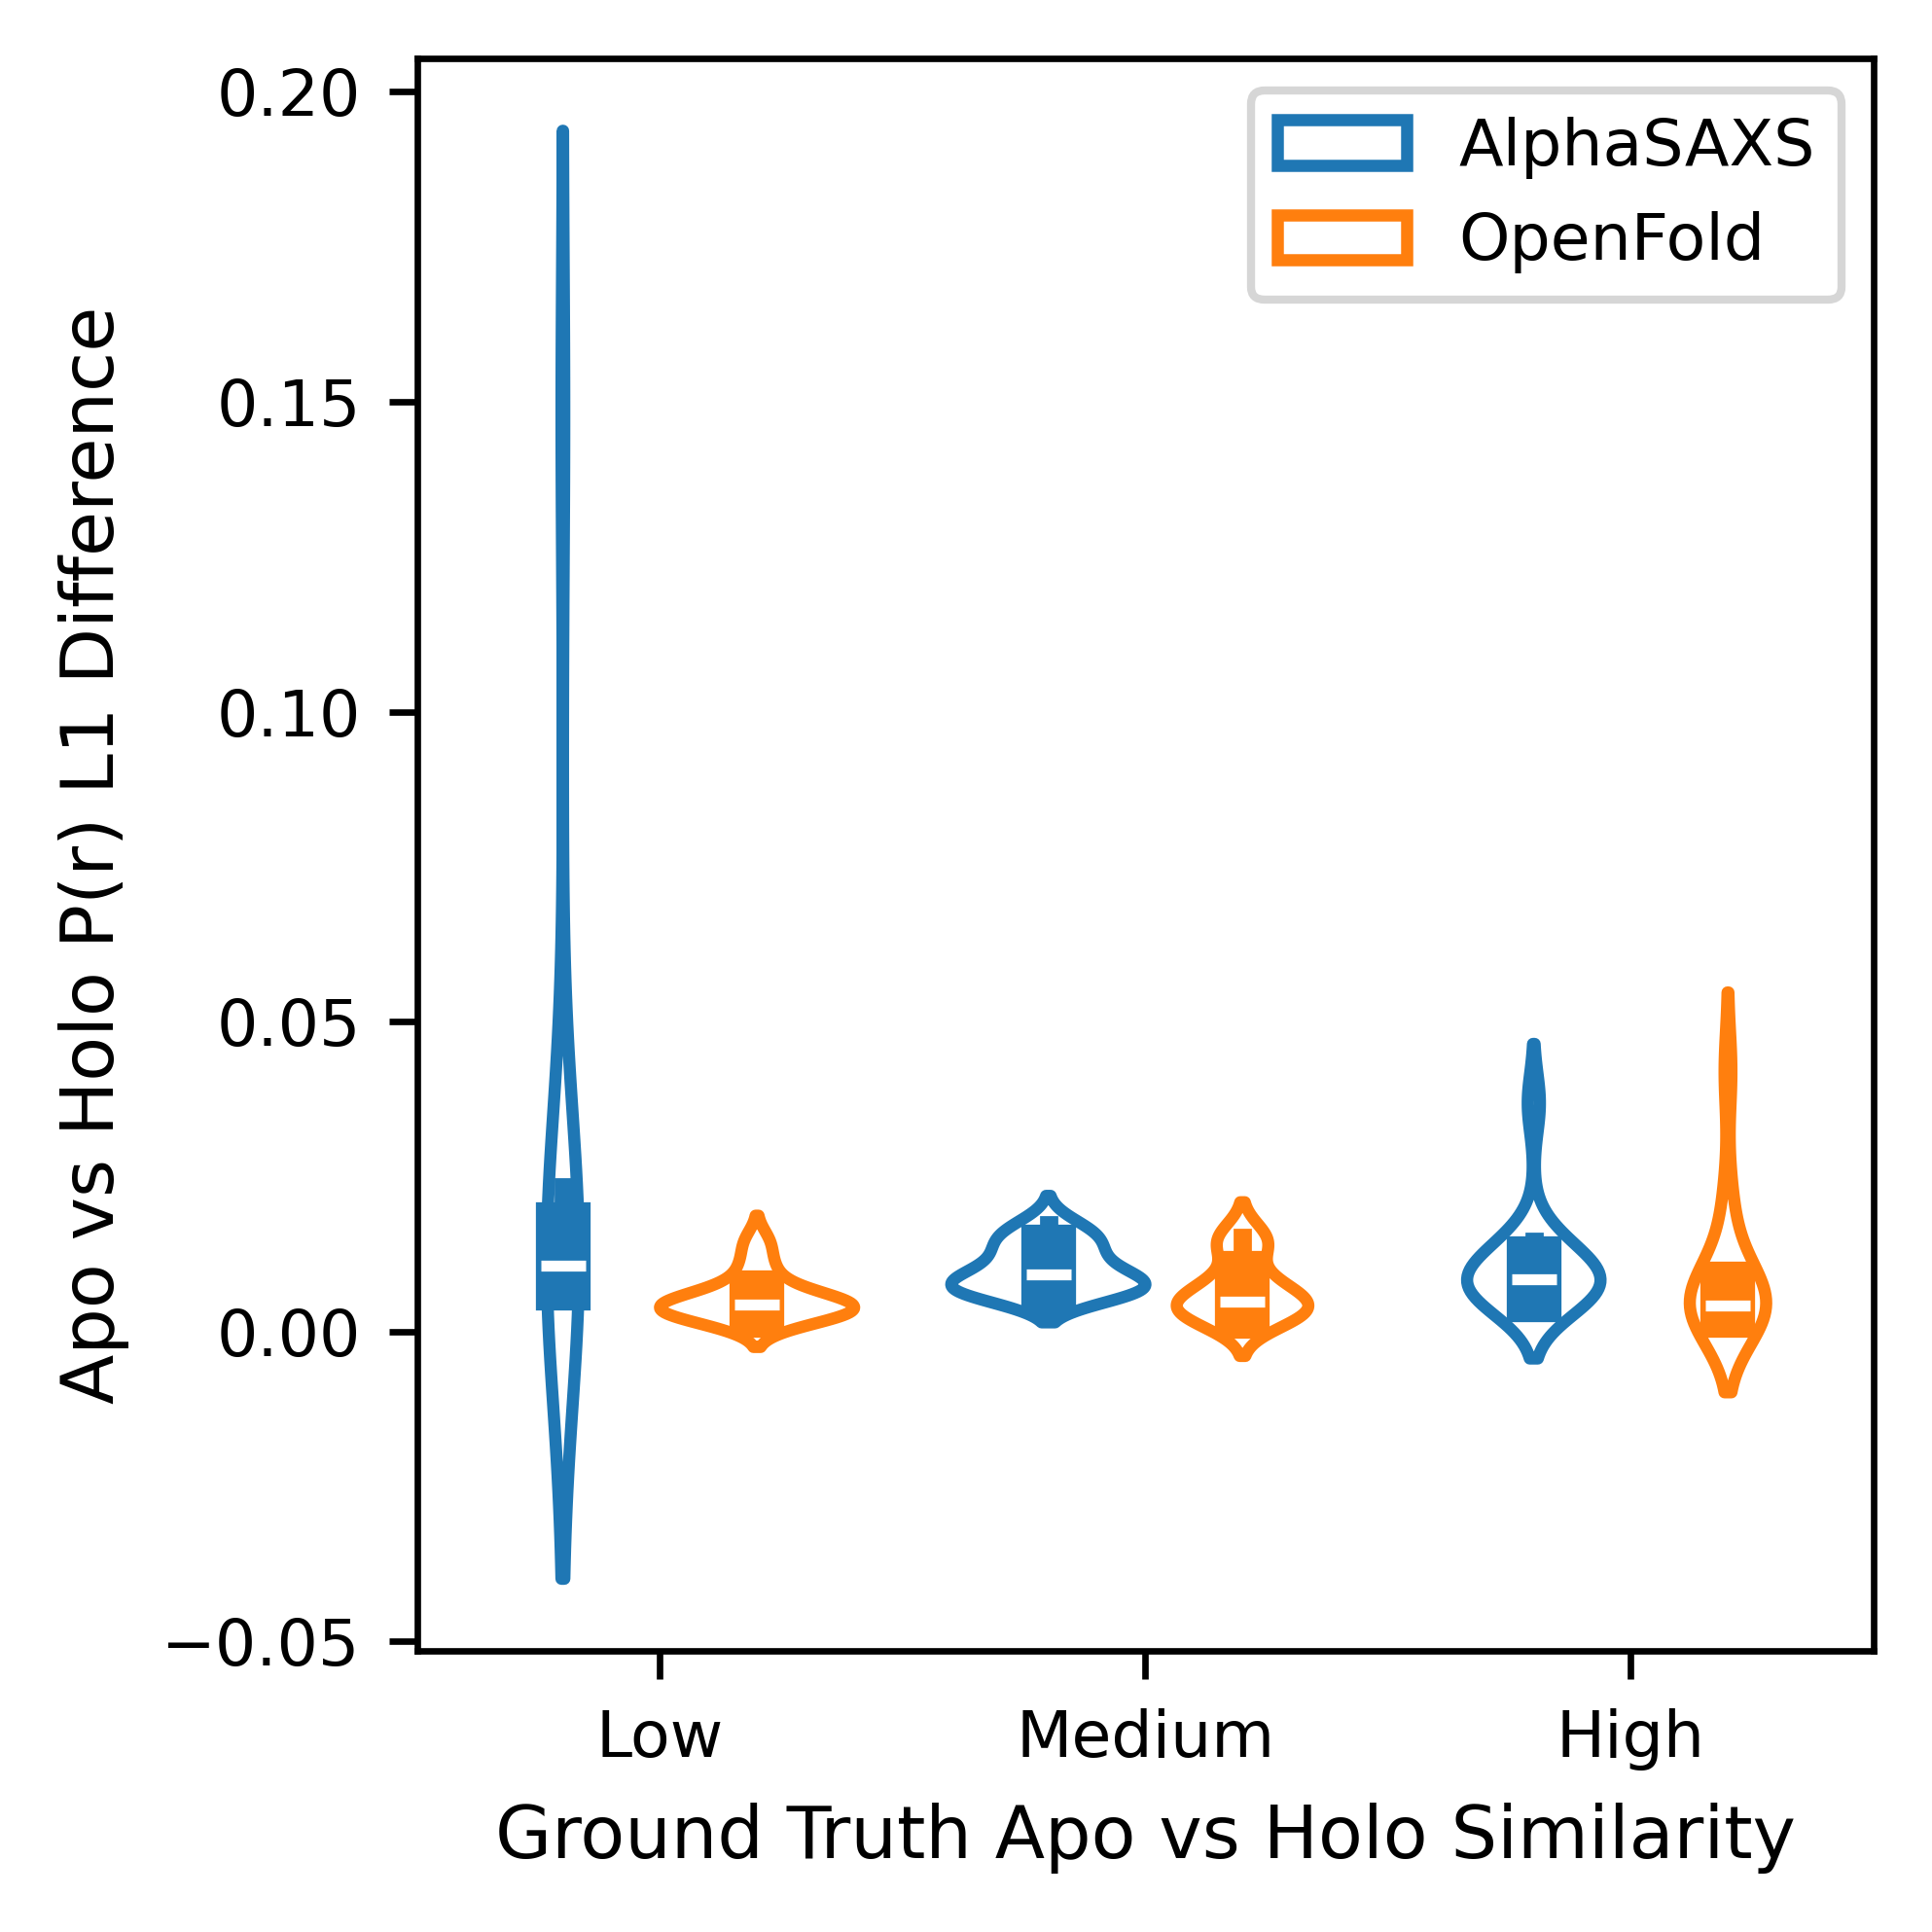

In [37]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600) # Single-column, high-res

sns.violinplot(y='saxs_l1',x='Apo vs Holo Similarity',hue='model',fill=False, data=plot_result, ax=ax,order=['Low', 'Medium', 'High'])
ax.set_xlabel('Ground Truth Apo vs Holo Similarity', labelpad=4)
ax.set_ylabel('Apo vs Holo P(r) L1 Difference', labelpad=4)
#ax.set_title('Violin Plot Example', fontsize=9, pad=8)

# Remove legend if it just duplicates x info, or set title to None
legend = ax.get_legend()
if legend:
    legend.set_title(None)

plt.tight_layout()
plt.savefig('Apo_Holo_Pr.png')

In [38]:
def get_saxs_profile(protein_df, protein_name):
    # 1. Filter once
    subset = protein_df[(protein_df['name'] == protein_name)&(protein_df['comparison'] == 'out_NMR_vs_target')]
    
    if subset.empty:
        print(f"Warning: {protein_name} not found.")
        return None, None

    # 2. Extract the raw item (could be a list, or a string that LOOKS like a list)
    raw_r = subset['saxs_bins_a'].iloc[0]
    raw_pr = subset['saxs_a'].iloc[0]

    # 3. Helper function to clean the data
    def clean_data(val):
        # If it is a string (e.g. "[1, 2, 3]"), parse it
        if isinstance(val, str):
            val = val.strip()
            # Scenario A: Comma-separated (standard list string)
            if ',' in val:
                return np.array(ast.literal_eval(val))
            # Scenario B: Space-separated (often how numpy arrays are saved to text)
            else:
                # Remove brackets and newlines, then convert by space separation
                clean_str = val.replace('[', '').replace(']', '').replace('\n', ' ')
                return np.fromstring(clean_str, sep=' ')
        
        # If it's already a list, just convert
        return np.array(val)

    # 4. Return clean arrays
    return clean_data(raw_r), clean_data(raw_pr)

(0.0, 0.02)

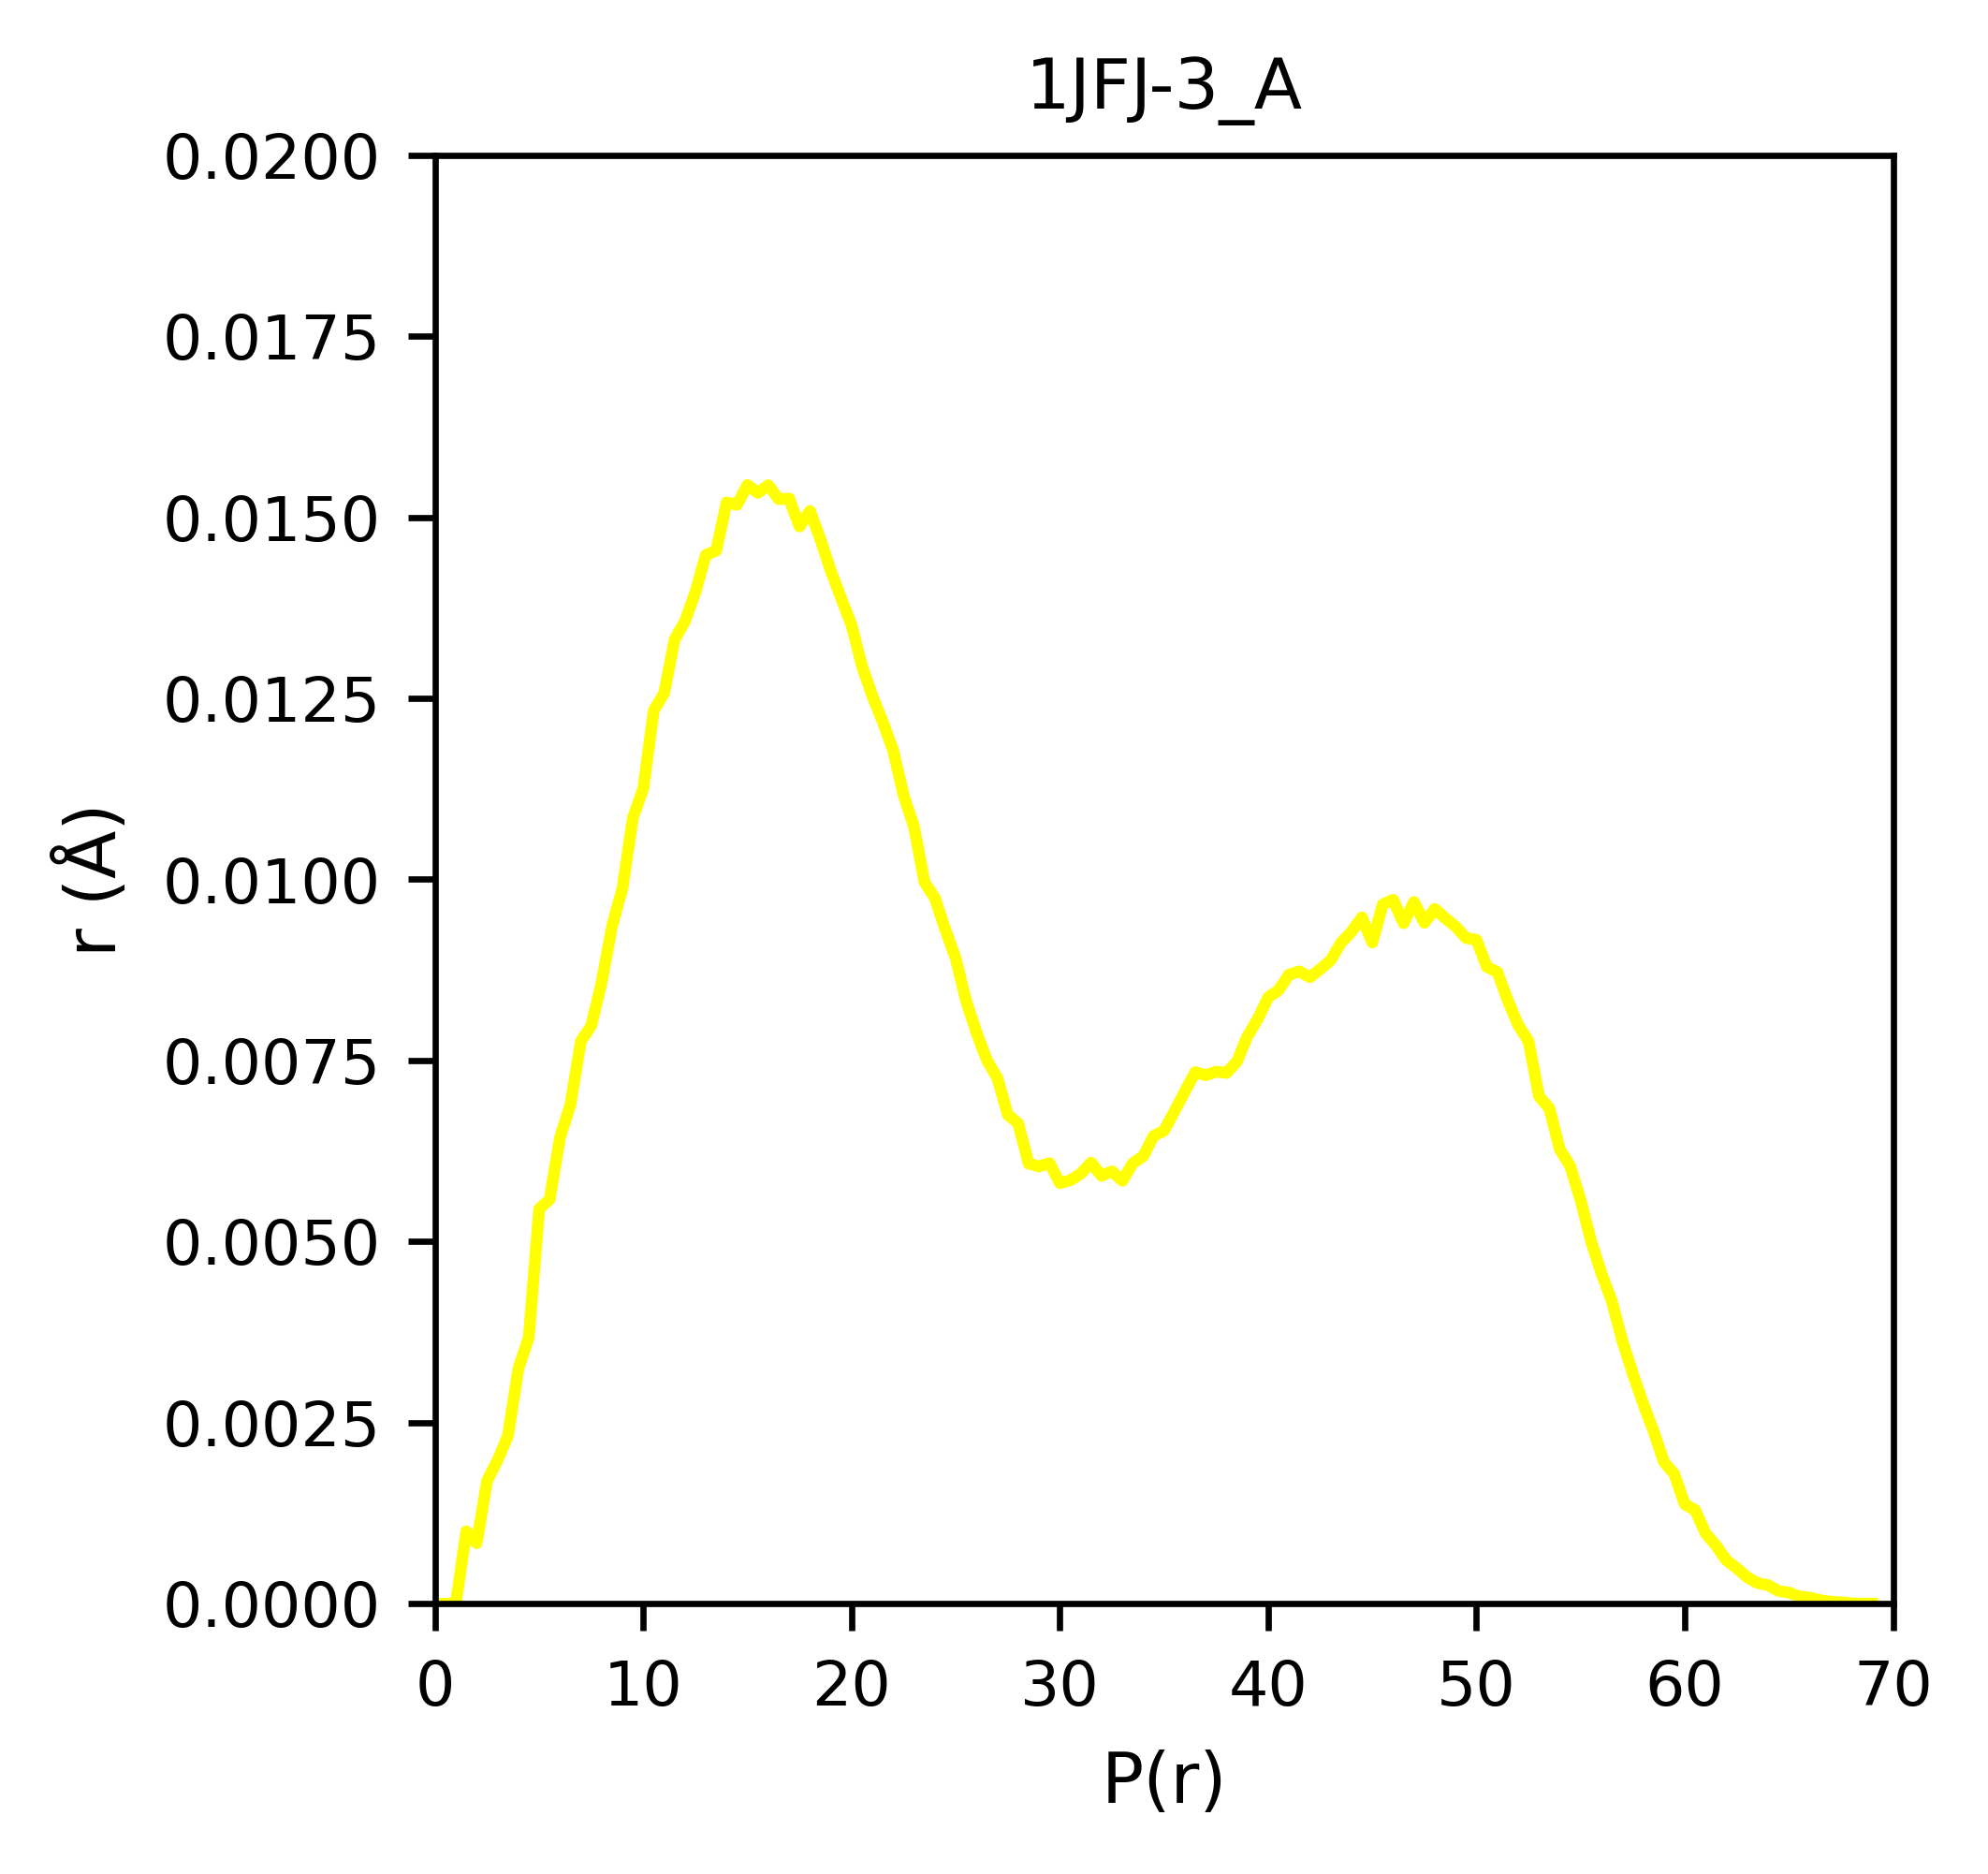

In [39]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600)
r_1JFJ, pr_1JFJ = get_saxs_profile(result,'1JFJ-3_A')
plt.plot(r_1JFJ,pr_1JFJ,color='yellow')
plt.xlabel('P(r)')
plt.ylabel('r (Å)')
plt.title('1JFJ-3_A')
plt.xlim(0,70)
plt.ylim(0,0.02)

(0.0, 0.02)

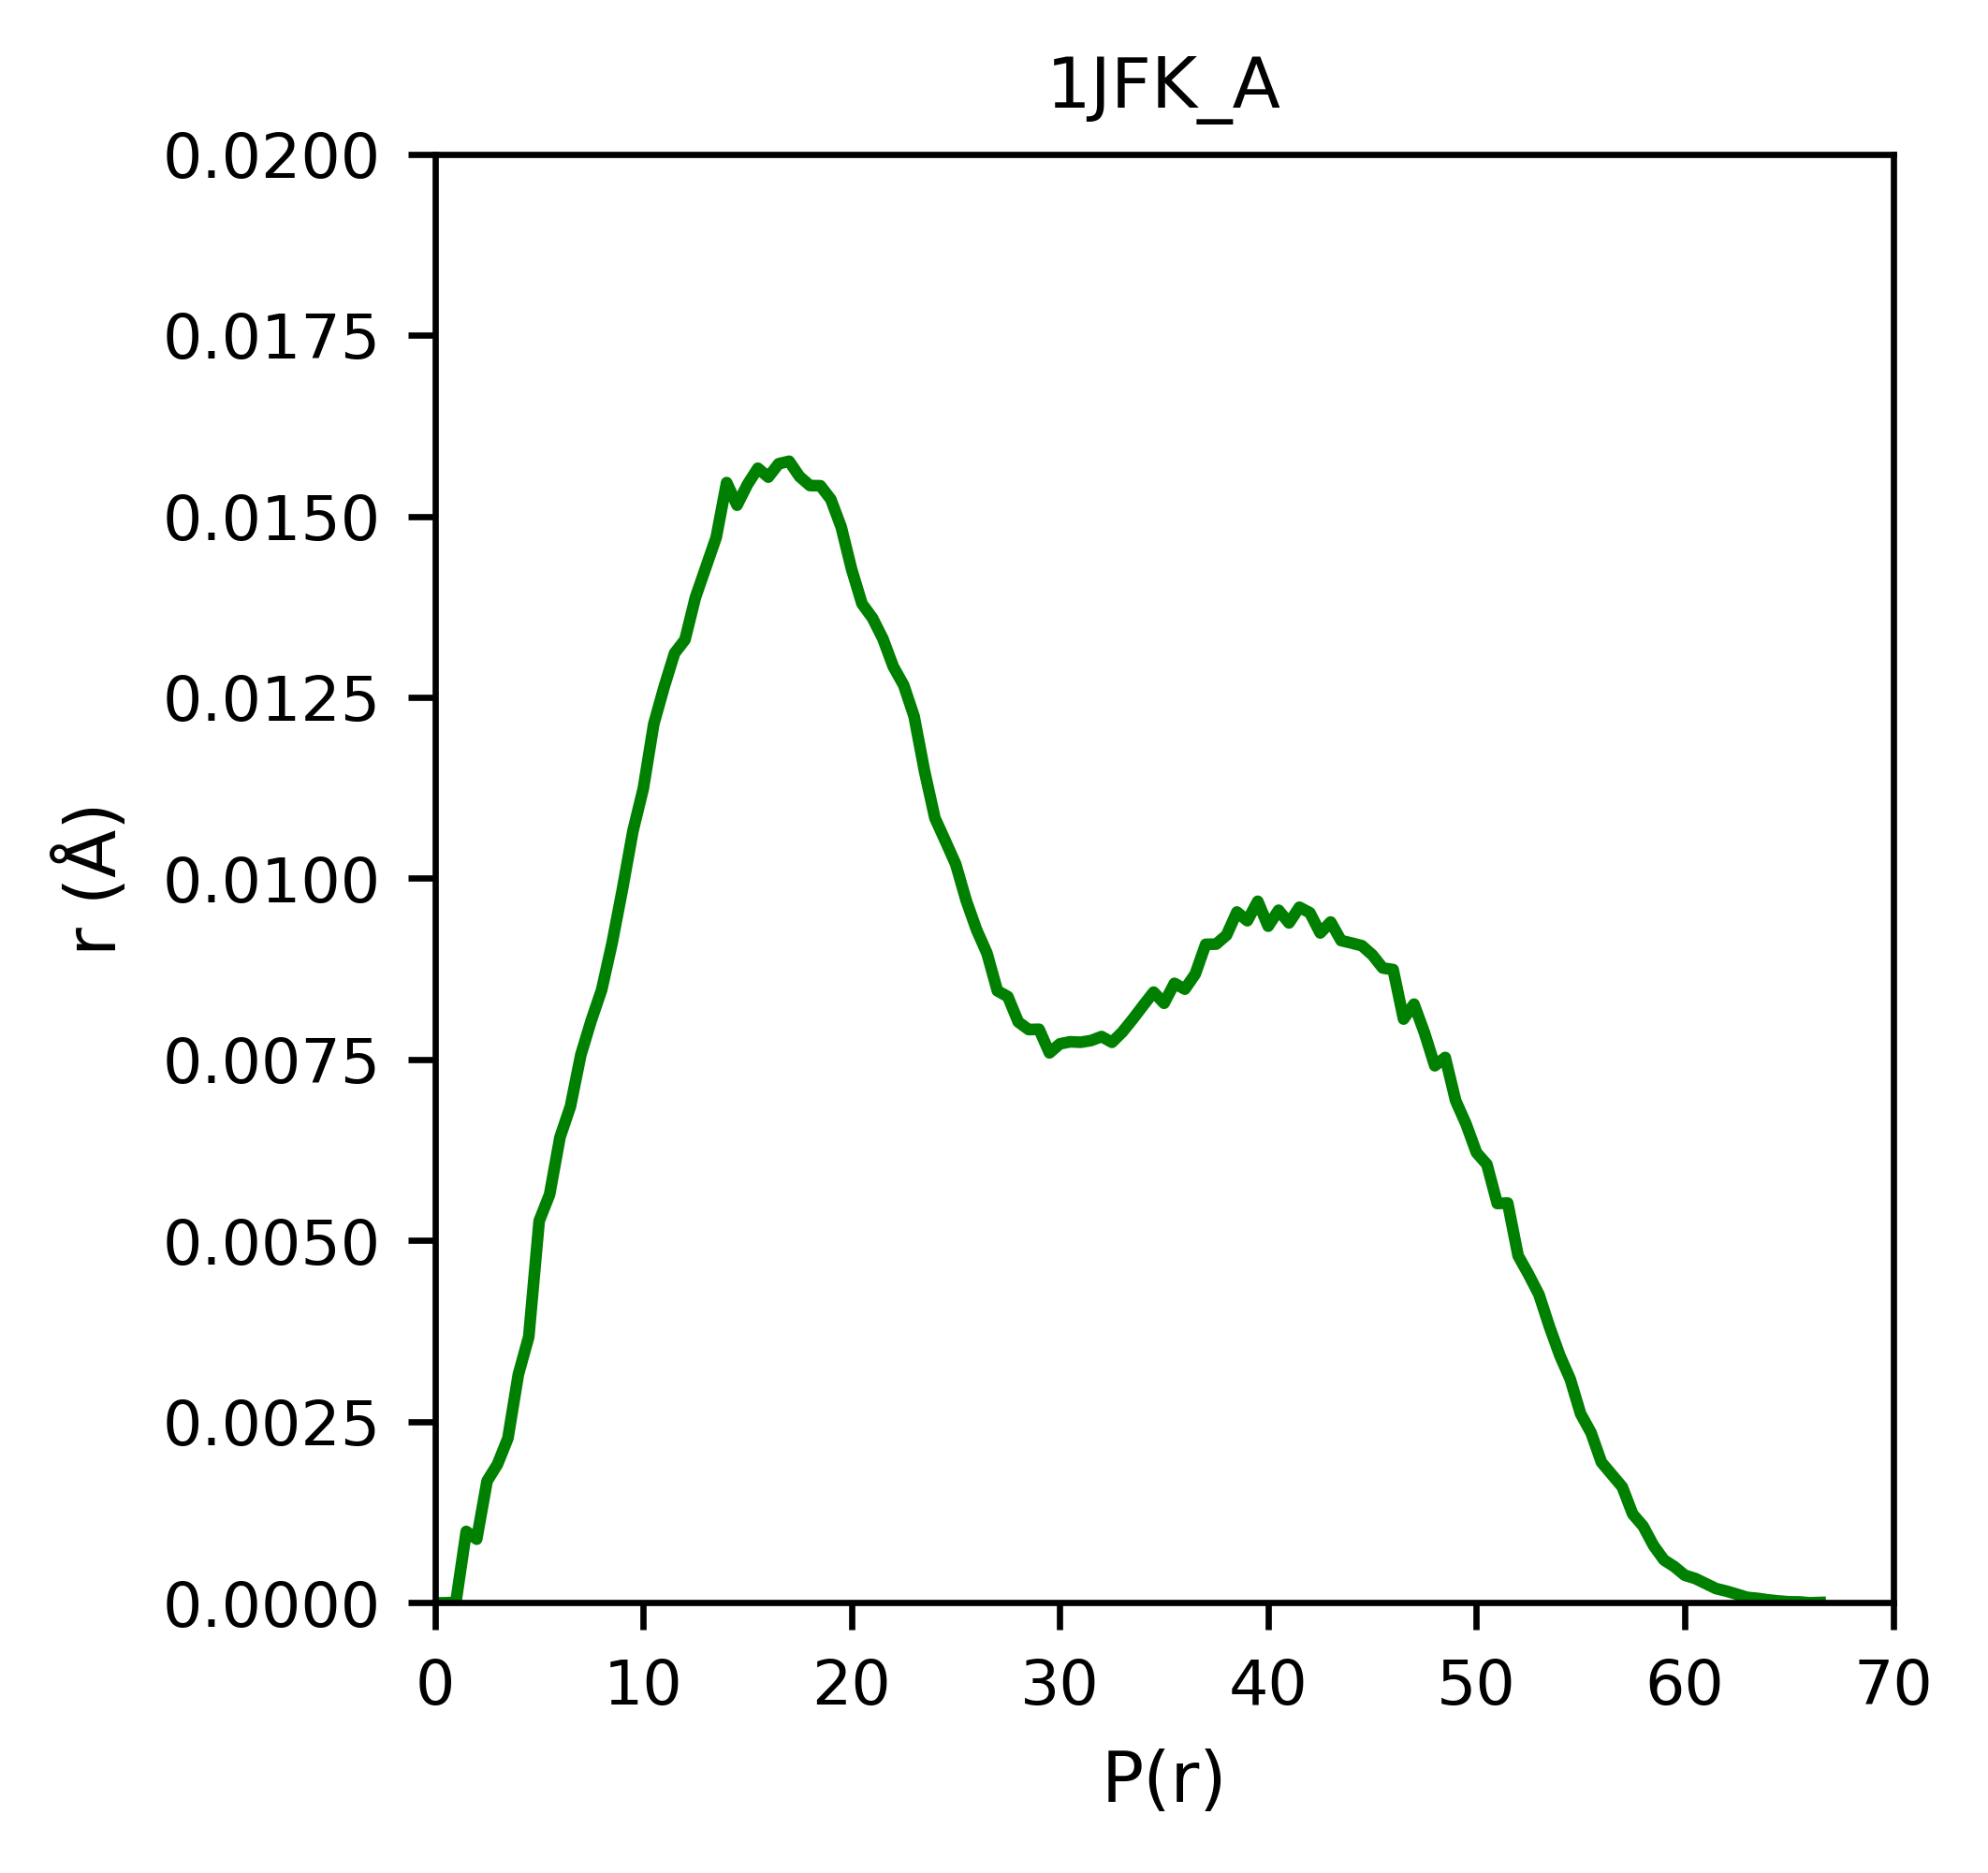

In [40]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600)
r_1JFK, pr_1JFK = get_saxs_profile(result,'1JFK_A')
plt.plot(r_1JFK,pr_1JFK,color='green')
plt.xlabel('P(r)')
plt.ylabel('r (Å)')
plt.title('1JFK_A')
plt.xlim(0,70)
plt.ylim(0,0.02)

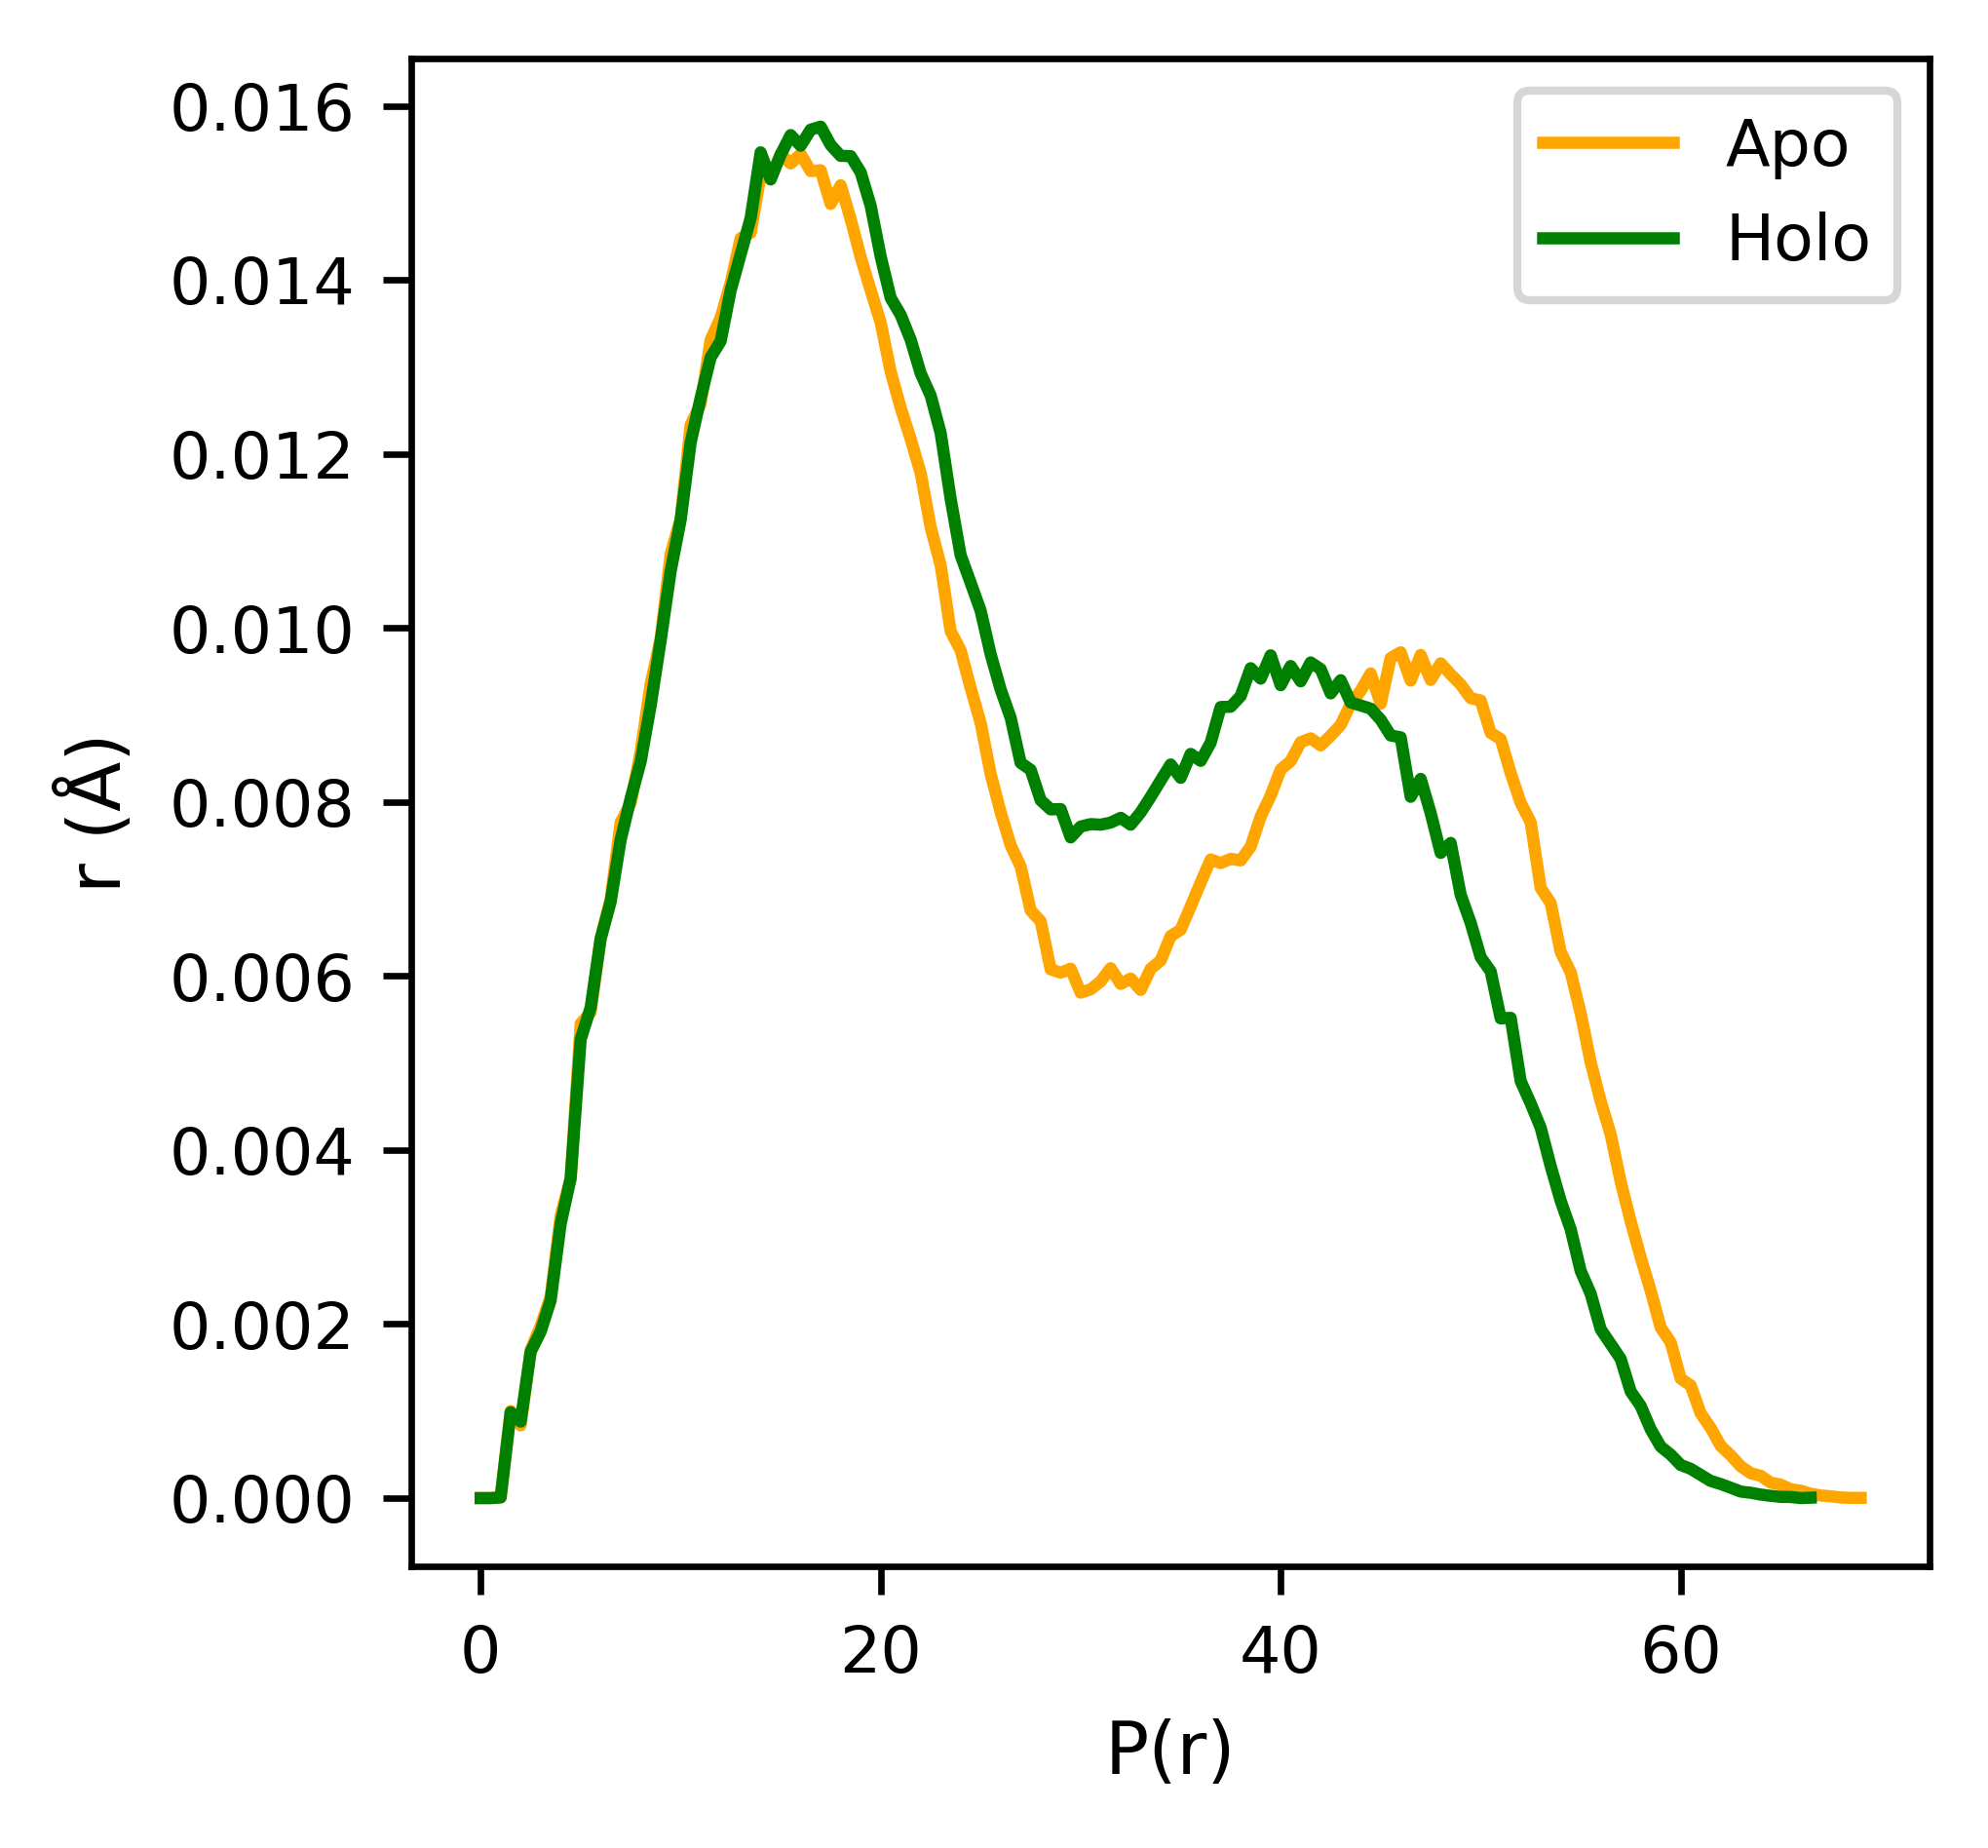

In [41]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600)
plt.plot(r_1JFJ,pr_1JFJ,color='orange',label='Apo')
plt.plot(r_1JFK,pr_1JFK,color='green',label='Holo')
plt.xlabel('P(r)')
plt.ylabel('r (Å)')
plt.legend()
plt.savefig('1JFJvs1JFK.png')

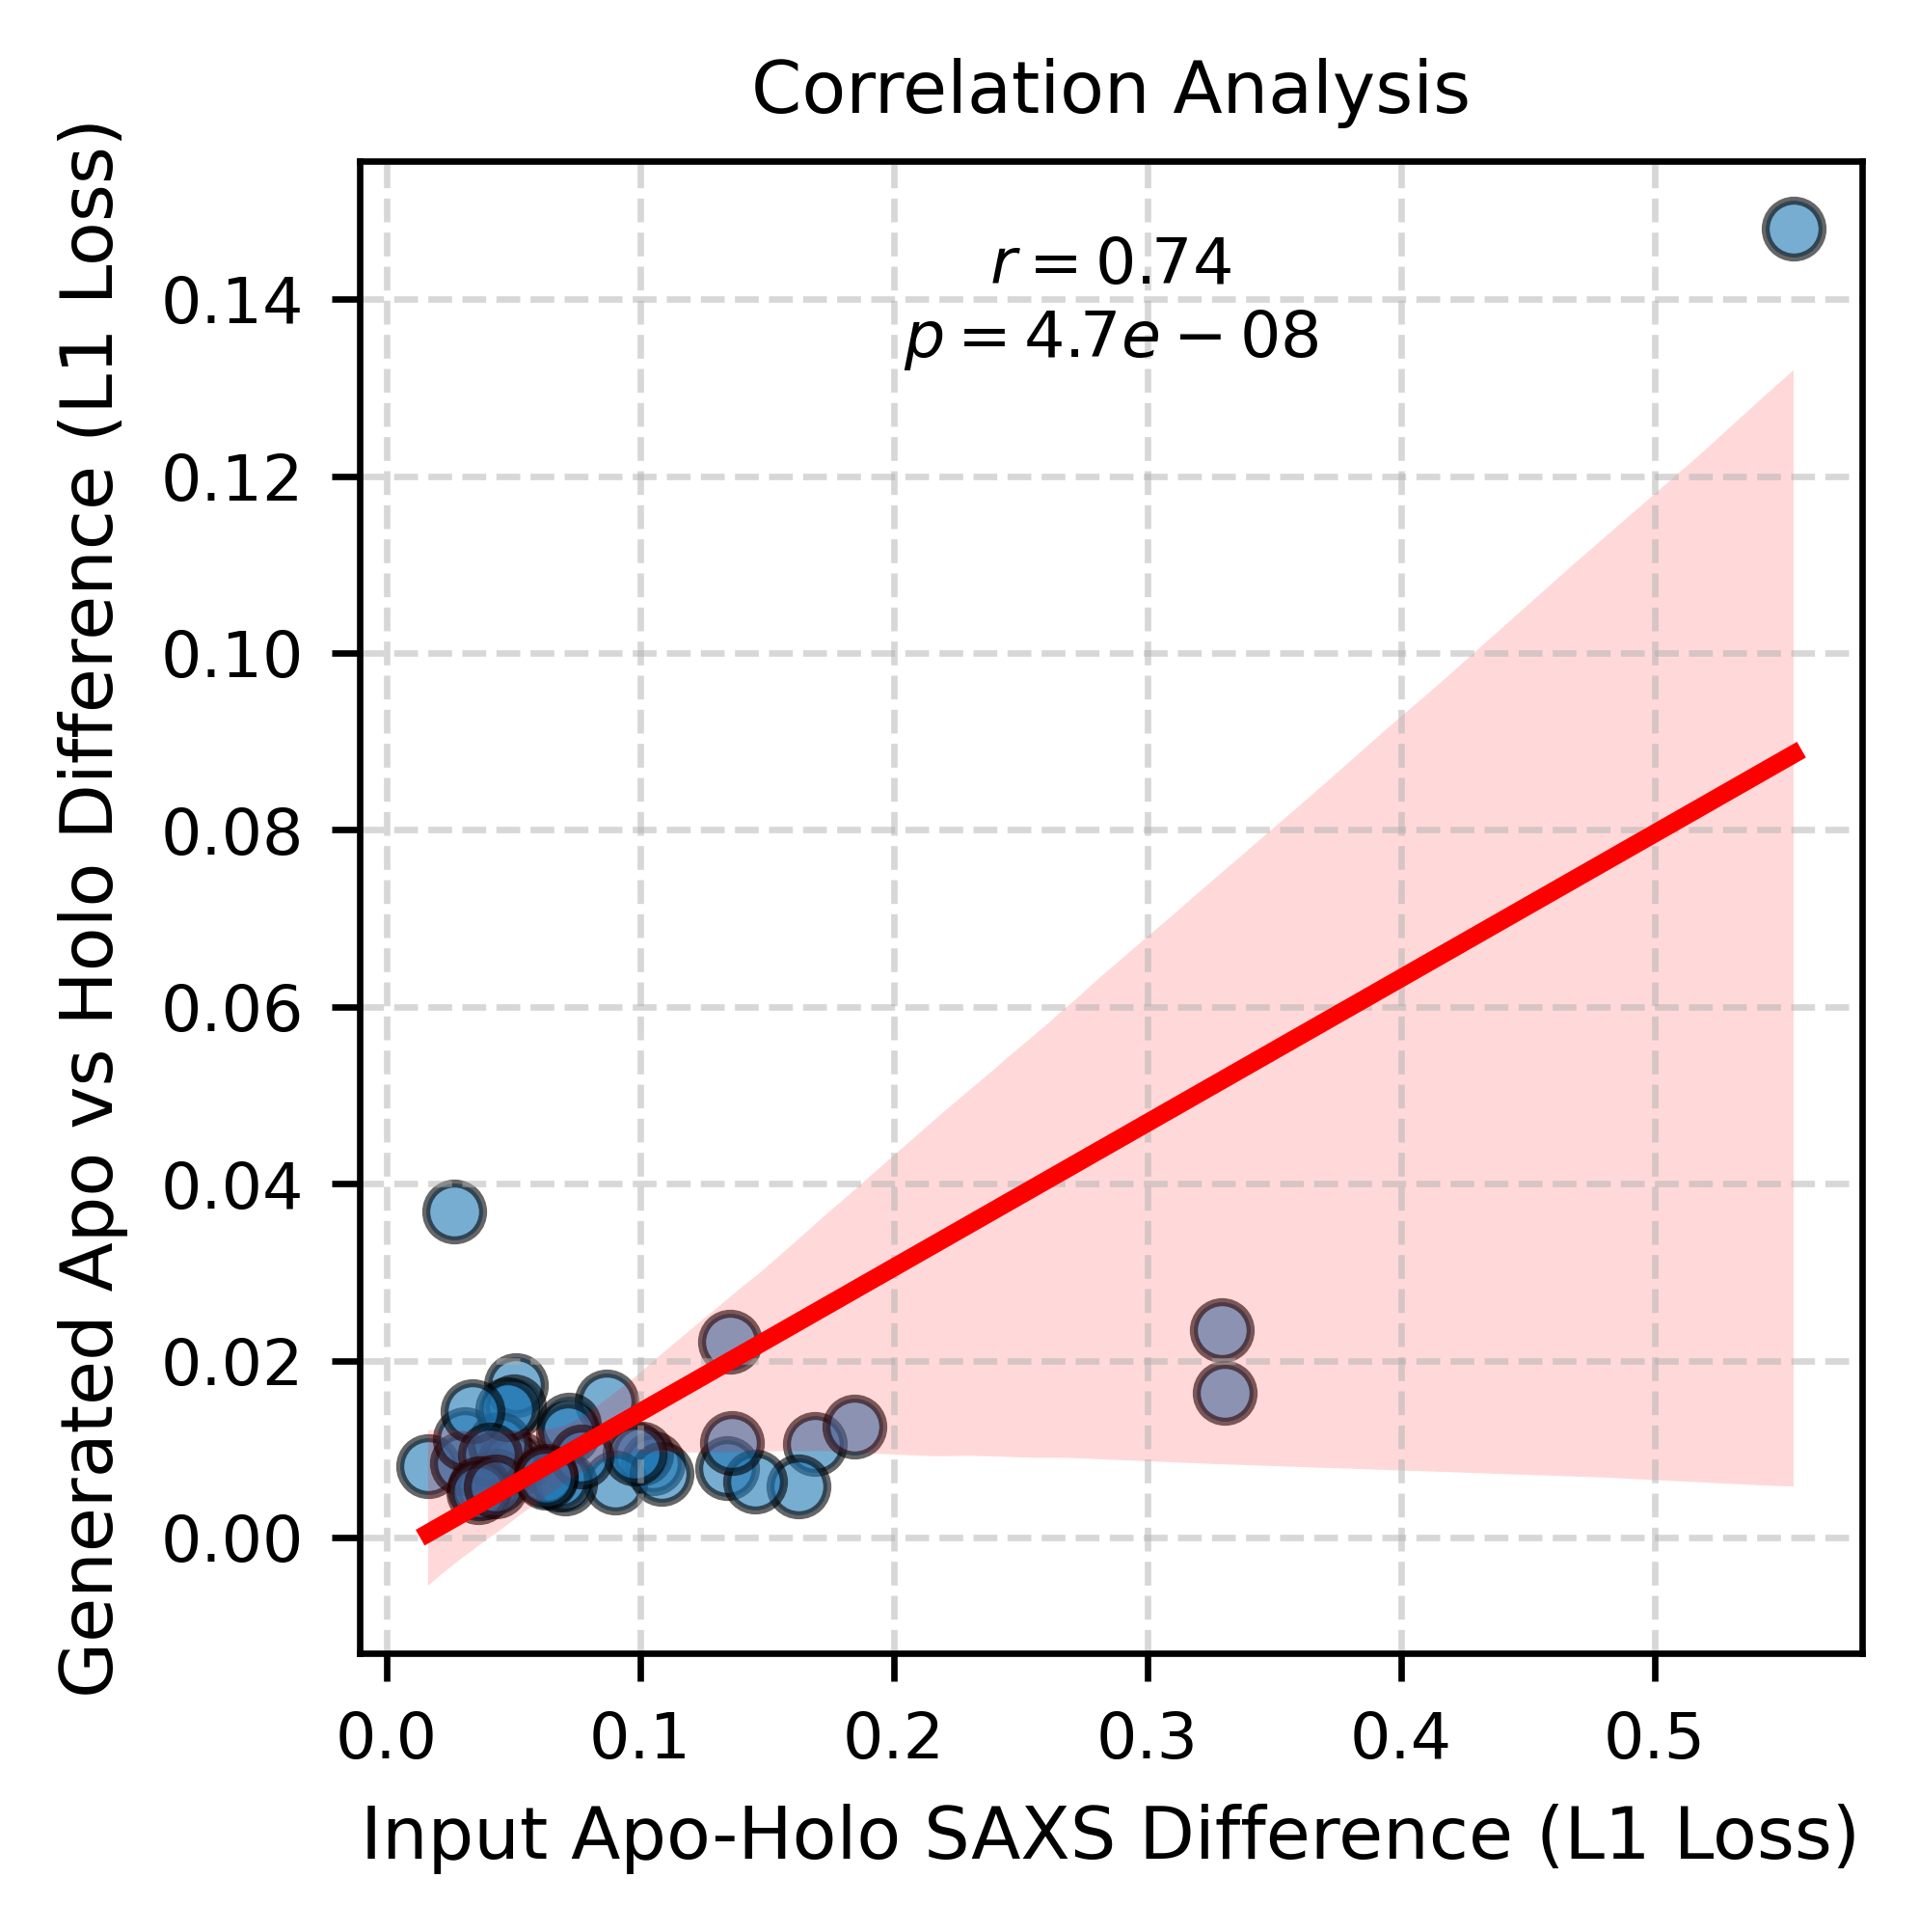

In [42]:
import scipy.stats as stats

# Assuming NMR_result_pair is your dataframe
x = NMR_result_pair['saxs_l1_ref']
y = NMR_result_pair['saxs_l1']

# 1. Calculate Pearson correlation
r, p_value = stats.pearsonr(x, y)

# 2. Plotting
plt.figure(figsize=(3.35, 3.35), dpi=600)

# distinct scatter and regression line
sns.regplot(x=x, y=y, scatter_kws={'s': 50, 'alpha': 0.6, 'edgecolor': 'k'}, line_kws={'color': 'red'})

# 3. Add Annotation
# Anchored text box for statistics
text_str = f'$r = {r:.2f}$\n$p = {p_value:.2g}$'
plt.gca().text(0.5, 0.95, text_str, transform=plt.gca().transAxes, verticalalignment='top', horizontalalignment='center')
plt.xlabel('Input Apo-Holo SAXS Difference (L1 Loss)')
plt.ylabel('Generated Apo vs Holo Difference (L1 Loss)')
plt.title('Correlation Analysis')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('correlation_plot.png')

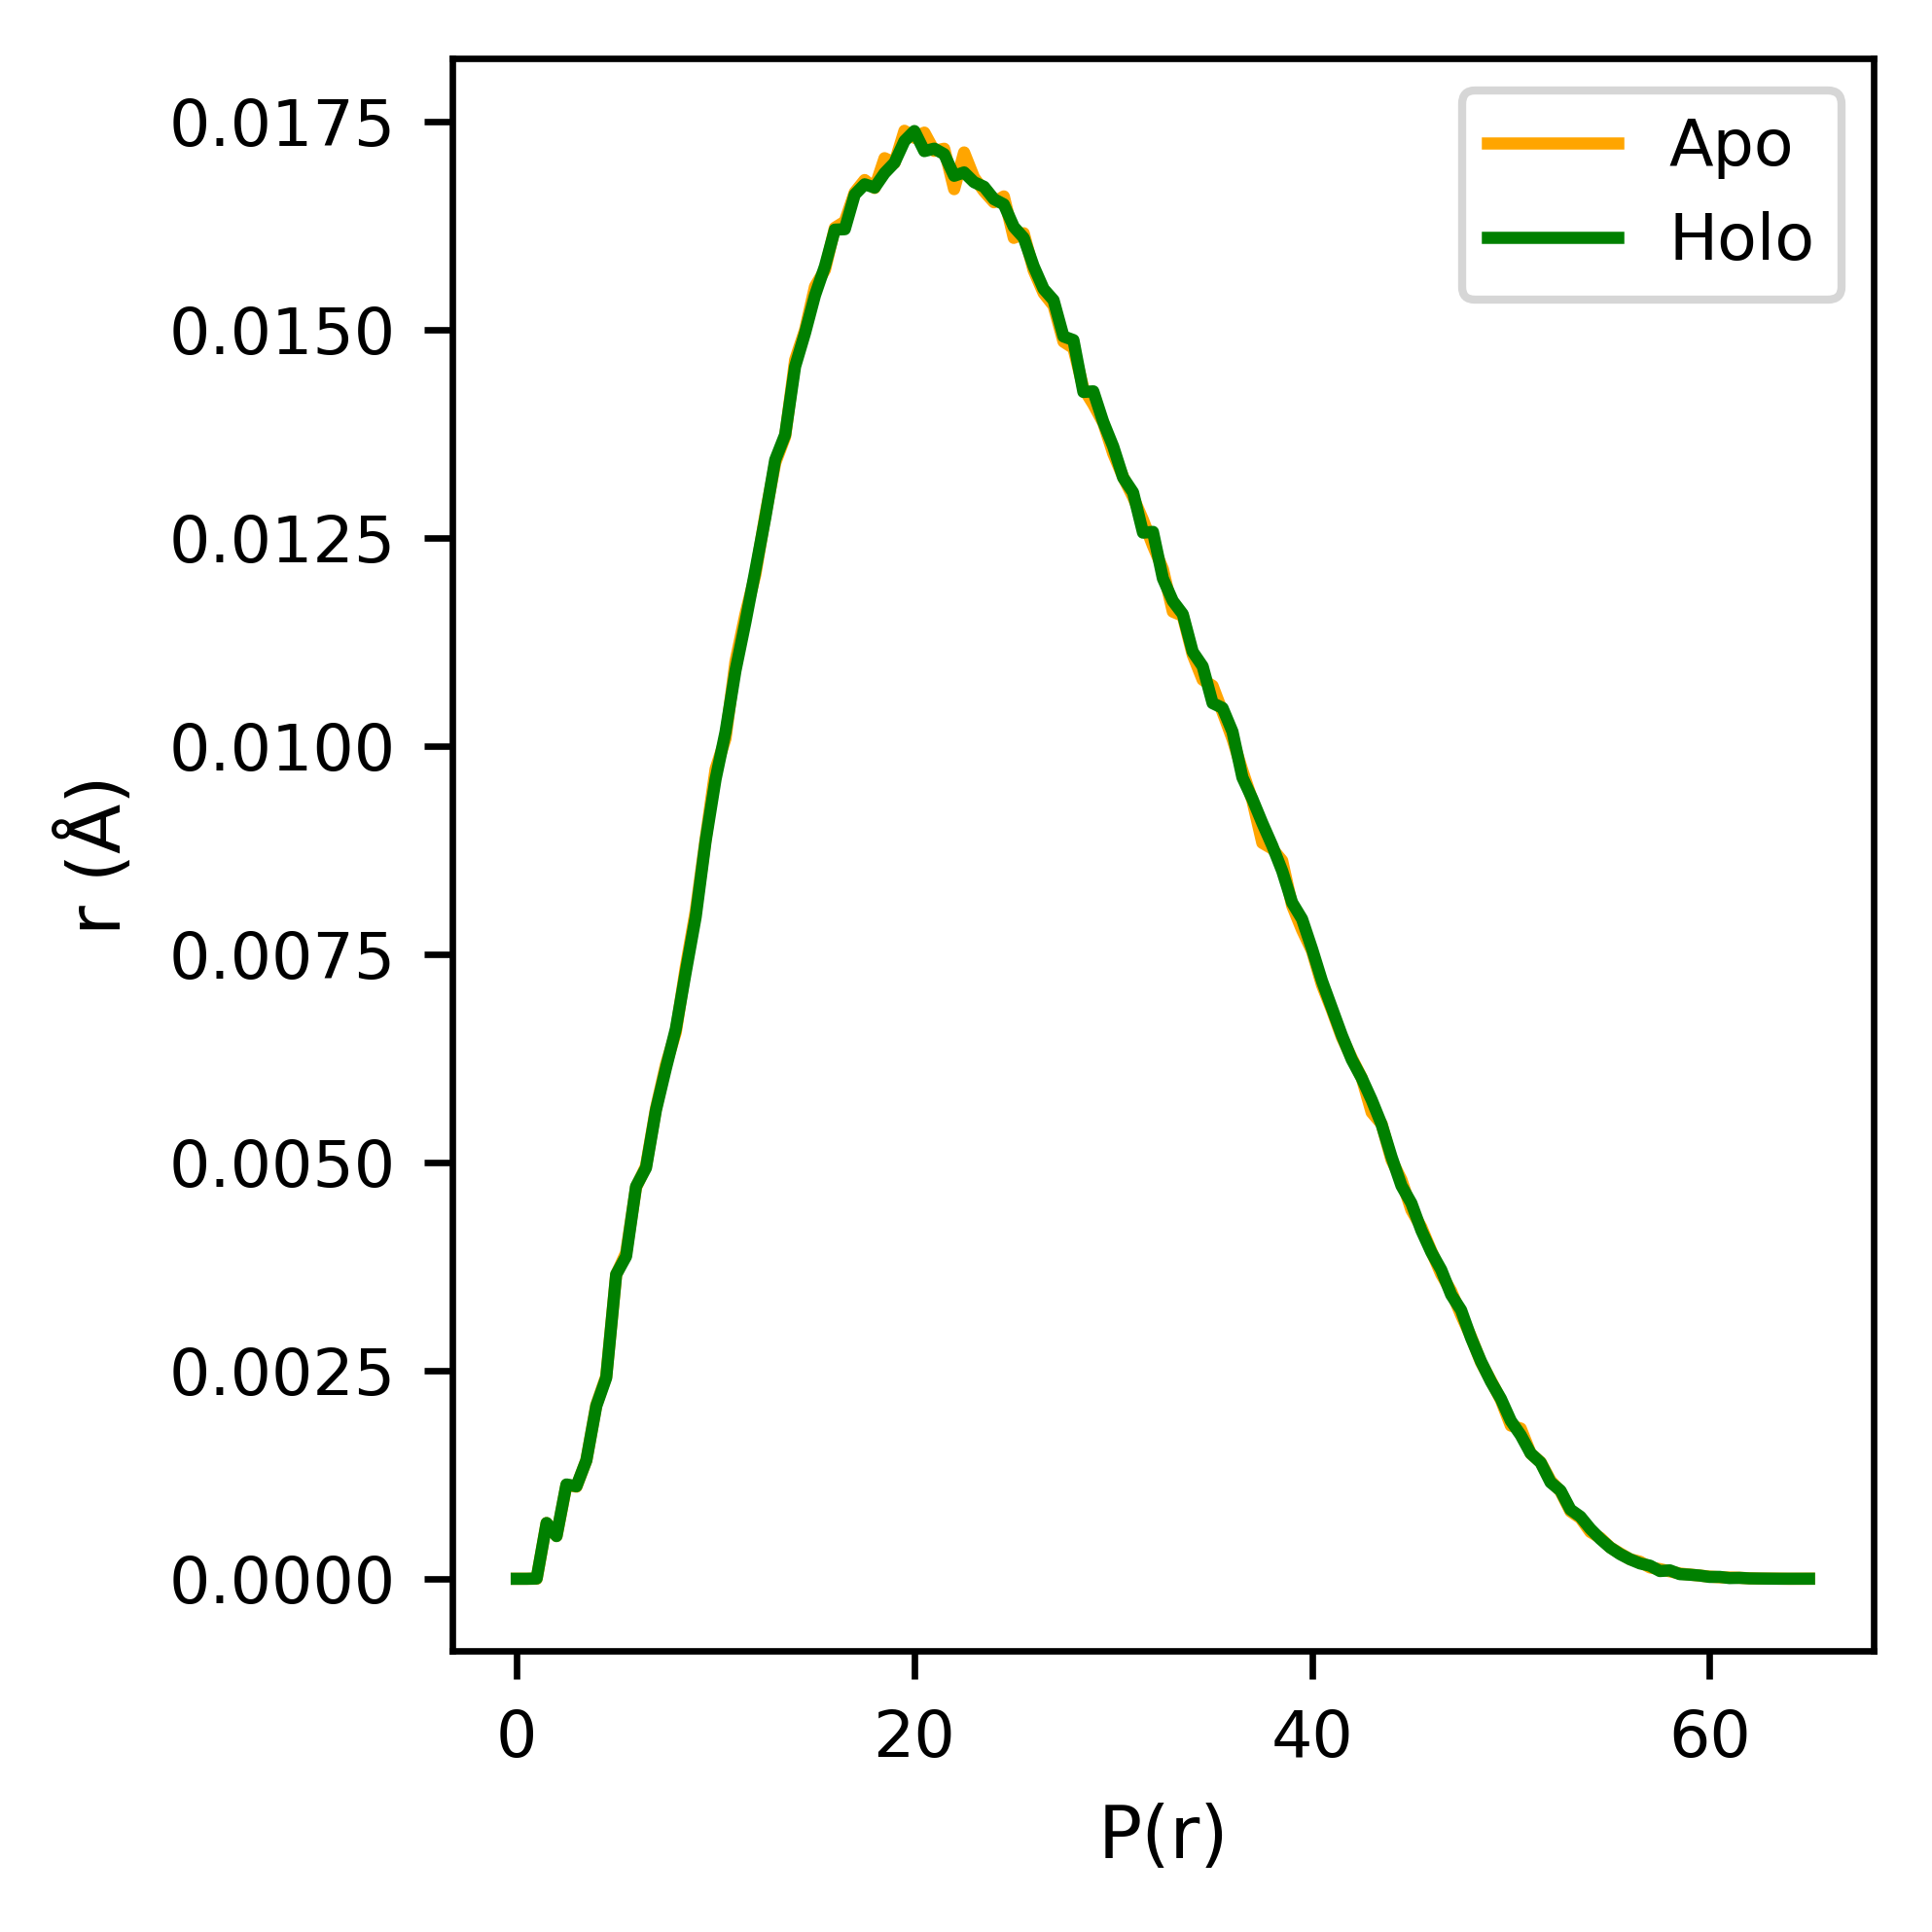

In [43]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600)
r_1TJD, pr_1TJD = get_saxs_profile(result,'1TJD_A')
r_1EEJ, pr_1EEJ = get_saxs_profile(result,'1EEJ_B')
plt.plot(r_1TJD,pr_1TJD,color='orange',label='Apo')
plt.plot(r_1EEJ,pr_1EEJ,color='green',label='Holo')
plt.xlabel('P(r)')
plt.ylabel('r (Å)')
plt.legend()
plt.tight_layout()
plt.savefig('1TJDvs1EEJ.png')